In [1]:
import numpy as np
import geopandas as gpd
import contextily as ctx
import os 
import h3
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Polygon, Point, box
from shapely.strtree import STRtree
from geopy.distance import geodesic
from pyproj import Transformer
from itertools import combinations
from math import pi, cos, sin, exp, sqrt, radians, atan2
import statsmodels.api as sm
import osmnx as ox
import networkx as nx
from tqdm import tqdm
import json
import seaborn as sns
from shapely import wkt
import requests
from time import sleep
import math

In [2]:
RESOLUTION = 7

In [3]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [4]:
### Process Income Data ###

hnwi_df = pd.read_csv('../data/Dubai HNWI.csv')

# --- Parse WKT into shapely geometries ---
hnwi_df["geometry"] = hnwi_df["WKT"].apply(wkt.loads)

# --- Explode GeometryCollections into multiple rows ---
gdf = gpd.GeoDataFrame(hnwi_df, geometry="geometry", crs="EPSG:4326")

# If geometry is a collection, turn into separate polygons
gdf = gdf.explode(index_parts=True, ignore_index=True)

# --- Reproject to Web Mercator for plotting with basemap ---
gdf_webmerc = gdf.to_crs(epsg=3857)

gdf_webmerc = gdf_webmerc.rename(columns={
    "WKT": "wkt",
    "Назва": "income_desc",
    "опис": "income_category",
    "name": "name"
})[['income_category', 'geometry']]

gdf_webmerc = gdf_webmerc.dissolve(by='income_category').reset_index()

In [5]:
### Import Raw Talabat Data ###

folder_path = '/Users/javad/SCL/talabat_data/mit_base_orders/'

# List all CSV files in the folder
csv_files = [file for file in os.listdir(folder_path) if file.endswith('.csv')]

# Initialize an empty list to store DataFrames
dfs = []
count = 0

# Loop through each CSV file, read it into a DataFrame, and append it to the list
for file in csv_files:
    file_path = os.path.join(folder_path, file)
    df = pd.read_csv(file_path)
    dfs.append(df.sample(frac=0.1))
    count += len(df)

# Concatenate all DataFrames in the list into one DataFrame
orders_df = pd.concat(dfs, ignore_index=True)


def extract_coords_fast(point_str):
    point = wkt.loads(point_str)
    return point.y, point.x


orders_df = pd.concat(dfs, ignore_index=True)[['order_id', 'account_id', 'vendor_id', 'location_id',
    'vendor_location', 'main_cuisine', 'vertical_class', 'secondary_verticals', 'delivery_fee_amount_lc',
    'service_fee_amount_lc', 'basket_amount_lc', 'customer_selected_location', 'picked_up_at',
    'delivered_at', 'is_incentive_applied', 'incentive_amount_lc']]


coords = orders_df['vendor_location'].apply(extract_coords_fast)
orders_df['vendor_lat'] = coords.apply(lambda x: x[0])
orders_df['vendor_lng'] = coords.apply(lambda x: x[1])
coords = orders_df['customer_selected_location'].apply(extract_coords_fast)
orders_df['customer_lat'] = coords.apply(lambda x: x[0])
orders_df['customer_lng'] = coords.apply(lambda x: x[1])



/var/folders/n6/07flntc946j046ynznszq86w0000gn/T/ipykernel_2446/2846151177.py:15: DtypeWarning: Columns (10,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
/var/folders/n6/07flntc946j046ynznszq86w0000gn/T/ipykernel_2446/2846151177.py:15: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
/var/folders/n6/07flntc946j046ynznszq86w0000gn/T/ipykernel_2446/2846151177.py:15: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
/var/folders/n6/07flntc946j046ynznszq86w0000gn/T/ipykernel_2446/2846151177.py:15: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
/var/folders/n6/07flntc946j046ynznszq86w0000gn/T/ipykernel_2446/2846151177.py:15: DtypeWarning: Columns (10) have mixed types. Specify dtype opti

In [6]:
### Incentive Data ###

folder_path = '/Users/javad/SCL/talabat_data/mit_base_orders_incentives/'

# List all CSV files in the folder
csv_files = [file for file in os.listdir(folder_path) if file.endswith('.csv')]

# Initialize an empty list to store DataFrames
dfs = []
count = 0

# Loop through each CSV file, read it into a DataFrame, and append it to the list
for file in csv_files:
    file_path = os.path.join(folder_path, file)
    df = pd.read_csv(file_path, compression='gzip')
    count += len(df)
    dfs.append(df)

# Concatenate all DataFrames in the list into one DataFrame
incentives_df = pd.concat(dfs, ignore_index=True)[['order_id', 'incentive_type', 'incentive_sub_type', 'incentive_amount_lc']]

incentives_df = incentives_df[
    (incentives_df['incentive_sub_type'] == 'free delivery') |
    (incentives_df['incentive_sub_type'] == 'discounted delivery')
]

In [7]:
incentives_df

,order_id,incentive_type,incentive_sub_type,incentive_amount_lc
2114,1075360500,vendor offers,discounted delivery,1.50
2115,1074939970,vendor offers,discounted delivery,1.50
2116,1075017328,vendor offers,discounted delivery,1.50
2117,1258567877,vendor offers,discounted delivery,1.50
2118,1259425929,vendor offers,discounted delivery,1.50
...,...,...,...,...
18516708,1023087941,vendor offers,free delivery,6.49
18526683,1023017562,vendor offers,free delivery,5.49
18526684,1023042642,vendor offers,free delivery,5.49
18526685,1022987984,vendor offers,free delivery,5.49


In [8]:
incentives_df.incentive_sub_type.value_counts()

incentive_sub_type
discounted delivery    1299669
free delivery          1156760
Name: count, dtype: int64

In [9]:
merged_df = orders_df.merge(incentives_df, on="order_id", how="left")

dubai_df = merged_df.rename(columns={
    "incentive_amount_lc_y": "delivery_incentive_lc",
    "incentive_amount_lc_x": "total_incentives_lc"
})

dubai_df['delivery_incentive_lc'] = dubai_df['delivery_incentive_lc'].fillna(0)
dubai_df['total_incentives_lc'] = dubai_df['total_incentives_lc'].fillna(0)
dubai_df['incentive_type'] = dubai_df['incentive_type'].fillna(0)
dubai_df['is_incentive_applied'] = dubai_df['is_incentive_applied'].fillna(False)

/var/folders/n6/07flntc946j046ynznszq86w0000gn/T/ipykernel_2446/1189421413.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dubai_df['is_incentive_applied'] = dubai_df['is_incentive_applied'].fillna(False)


In [10]:
dubai_df.isnull().sum()

order_id                            0
account_id                          0
vendor_id                           0
location_id                         0
vendor_location                     0
main_cuisine                      101
vertical_class                      0
secondary_verticals           3797614
delivery_fee_amount_lc              0
service_fee_amount_lc               0
basket_amount_lc                    0
customer_selected_location          0
picked_up_at                       56
delivered_at                      645
is_incentive_applied                0
total_incentives_lc                 0
vendor_lat                          0
vendor_lng                          0
customer_lat                        0
customer_lng                        0
incentive_type                      0
incentive_sub_type            3626996
delivery_incentive_lc               0
dtype: int64

<Axes: >

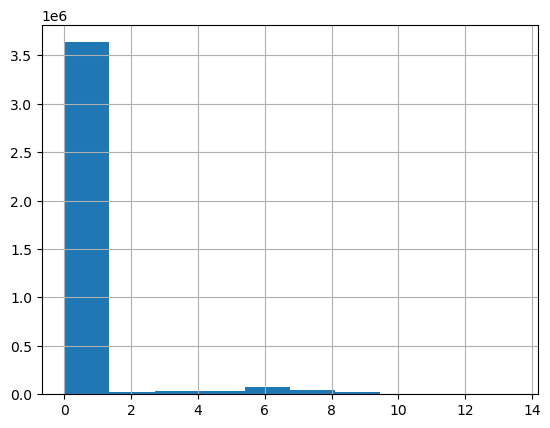

In [11]:
dubai_df['delivery_incentive_lc'].hist()

In [12]:
# Convert timestamp
dubai_df['picked_up_at'] = pd.to_datetime(
    dubai_df['picked_up_at'], 
    utc=True, 
    format="mixed"
)

# -----------------------------
# 1. Time-of-day categorization
# -----------------------------
def time_of_day(hour):
    if 5 <= hour < 12:
        return "morning"
    elif 12 <= hour < 17:
        return "afternoon"
    elif 17 <= hour < 22:
        return "evening"
    else:
        return "night"

dubai_df['time_period'] = dubai_df['picked_up_at'].dt.hour.map(time_of_day)

# -----------------------------
# 2. Workday vs weekend (UAE: Sat-Sun)
# -----------------------------
uae_weekend = [5, 6]   # Saturday=5, Sunday=6

def day_type(dt):
    if dt.weekday() in uae_weekend:
        return "weekend"
    else:
        return "workday"

dubai_df['day_type'] = dubai_df['picked_up_at'].apply(day_type)

# -----------------------------
# 3. Quarter/Season
# -----------------------------
dubai_df['quarter'] = dubai_df['picked_up_at'].dt.quarter
dubai_df['quarter'] = dubai_df['quarter'].map({1: "Q1", 2: "Q2", 3: "Q3", 4: "Q4"})

# -----------------------------
# 4. Vertical Category
# -----------------------------
def vertical_class(val):
    if pd.isna(val):
        return "non-food"
    v = val.lower()
    if v=='food':
        return "food"
    else:
        return "non-food"
        
dubai_df['vertical_class'] = dubai_df['vertical_class'].apply(vertical_class)


# -----------------------------
# Create 96 datasets in memory
# -----------------------------
datasets = {}   # dictionary of DataFrames

time_periods = ["morning", "afternoon", "evening", "night"]
day_types = ["workday", "weekend"]
quarters = ["Q1", "Q2", "Q3", "Q4"]
verticals = ["food", "non-food"]

for t in time_periods:
    for d in day_types:
        for q in quarters:
            for v in verticals:

                subset = dubai_df[
                    (dubai_df['time_period'] == t) &
                    (dubai_df['day_type'] == d) &
                    (dubai_df['quarter'] == q) &
                    (dubai_df['vertical_class'] == v)
                ]

                datasets[(t, d, q, v)] = subset


# Result: 96 in-memory DataFrames
len(datasets)


64

In [13]:
for key, df_subset in sorted(datasets.items()):
    t, d, q, v = key
    print(f"{t:9} | {d:8} | {q} | {v:7} → {len(df_subset)} rows")


afternoon | weekend  | Q1 | food    → 73032 rows
afternoon | weekend  | Q1 | non-food → 15445 rows
afternoon | weekend  | Q2 | food    → 77597 rows
afternoon | weekend  | Q2 | non-food → 17853 rows
afternoon | weekend  | Q3 | food    → 84197 rows
afternoon | weekend  | Q3 | non-food → 19060 rows
afternoon | weekend  | Q4 | food    → 93016 rows
afternoon | weekend  | Q4 | non-food → 22302 rows
afternoon | workday  | Q1 | food    → 168991 rows
afternoon | workday  | Q1 | non-food → 38927 rows
afternoon | workday  | Q2 | food    → 178219 rows
afternoon | workday  | Q2 | non-food → 42601 rows
afternoon | workday  | Q3 | food    → 187922 rows
afternoon | workday  | Q3 | non-food → 44341 rows
afternoon | workday  | Q4 | food    → 203064 rows
afternoon | workday  | Q4 | non-food → 51316 rows
evening   | weekend  | Q1 | food    → 49899 rows
evening   | weekend  | Q1 | non-food → 9879 rows
evening   | weekend  | Q2 | food    → 58773 rows
evening   | weekend  | Q2 | non-food → 11716 rows
evening

In [14]:
# -------------------------
# Helper Functions
# -------------------------

def haversine_vectorized(lon1, lat1, lon2, lat2):
    """
    Vectorized haversine distance calculation.
    Works with pandas Series or numpy arrays.
    Returns distance in kilometers.
    """
    # Convert to radians
    lon1_rad = np.radians(lon1)
    lat1_rad = np.radians(lat1)
    lon2_rad = np.radians(lon2)
    lat2_rad = np.radians(lat2)
    
    # Haversine formula
    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad
    
    a = np.sin(dlat/2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Radius of earth in kilometers
    r = 6371
    
    return c * r


def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate haversine distance between two points (scalar version).
    Returns distance in kilometers.
    """
    from math import radians, cos, sin, asin, sqrt
    
    # Convert to radians
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    
    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    
    # Radius of earth in kilometers
    r = 6371
    
    return c * r


def compute_basic_metrics(raw_df):
    """Compute distance, travel time, and fee metrics."""
    df = raw_df.copy()
    
    # Time metrics
    df["picked_up_at"] = pd.to_datetime(df["picked_up_at"], utc=True, errors="coerce")
    df["delivered_at"] = pd.to_datetime(df["delivered_at"], utc=True, errors="coerce")
    df["travel_time"] = (df["delivered_at"] - df["picked_up_at"]).dt.total_seconds() / 60.0
    
    # Euclidean distance metrics (from raw coordinates) - USING VECTORIZED VERSION
    df["euclidean_km"] = haversine_vectorized(
        df["vendor_lng"], df["vendor_lat"],
        df["customer_lng"], df["customer_lat"]
    )
    
    # Derived metrics
    df["min_to_km_ratio"] = df["travel_time"] / df["euclidean_km"]
    df["perc_discounted"] = df['delivery_incentive_lc'].fillna(0) / df['delivery_fee_amount_lc']
    df["fee_per_minute"] = df["delivery_fee_amount_lc"] / df["travel_time"]
    df["fee_per_km"] = df["delivery_fee_amount_lc"] / df["euclidean_km"]
    
    return df


def create_bbox(min_lon=55.0, min_lat=24.9, max_lon=55.45, max_lat=25.4, buffer=0.1):
    """Create bounding box for Dubai with buffer."""
    return box(
        min_lon - buffer, 
        min_lat - buffer, 
        max_lon + buffer, 
        max_lat + buffer
    )


def filter_income_polygons(gdf_webmerc, bbox):
    """Filter income polygons to bounding box."""
    gdf = gdf_webmerc.to_crs("EPSG:4326")
    return gdf[gdf.intersects(bbox)].copy()


def generate_h3_cells(bbox, h3_res):
    """Generate H3 candidate cells within bounding box."""
    outer_ring = [[y, x] for x, y in bbox.exterior.coords[:]]
    latlng_poly = h3.LatLngPoly(outer_ring)
    all_cells = set(h3.polygon_to_cells(latlng_poly, res=h3_res))
    
    filtered_cells = []
    polygons = []
    for cell in all_cells:
        poly_coords = [(lng, lat) for lat, lng in h3.cell_to_boundary(cell)]
        poly = Polygon(poly_coords)
        if bbox.contains(poly.centroid):
            filtered_cells.append(cell)
            polygons.append(poly)
    
    return gpd.GeoDataFrame(
        {'h3_index': filtered_cells, 'geometry': polygons}, 
        crs="EPSG:4326"
    )


def filter_trips_to_bbox(raw_df, bbox, input_crs="EPSG:4326"):
    """Filter trips where both vendor & customer fall inside bbox."""
    vendor_points = gpd.GeoSeries(
        [Point(xy) for xy in zip(raw_df['vendor_lng'], raw_df['vendor_lat'])], 
        crs=input_crs
    )
    customer_points = gpd.GeoSeries(
        [Point(xy) for xy in zip(raw_df['customer_lng'], raw_df['customer_lat'])], 
        crs=input_crs
    )
    
    if input_crs != "EPSG:4326":
        vendor_points = vendor_points.to_crs("EPSG:4326")
        customer_points = customer_points.to_crs("EPSG:4326")
    
    vendor_inside = vendor_points.within(bbox).to_numpy()
    customer_inside = customer_points.within(bbox).to_numpy()
    
    return raw_df[vendor_inside & customer_inside].reset_index(drop=True)


def assign_h3_indices(df, h3_res):
    """Assign H3 indices to trip origins and destinations."""
    df['origin'] = df.apply(
        lambda row: h3.latlng_to_cell(row['vendor_lat'], row['vendor_lng'], h3_res), 
        axis=1
    )
    df['destination'] = df.apply(
        lambda row: h3.latlng_to_cell(row['customer_lat'], row['customer_lng'], h3_res), 
        axis=1
    )
    return df


def compute_vendor_entropy(df, groupby_col):
    """
    Compute vendor entropy (diversity) for each H3 cell.
    Higher entropy = more diverse vendor distribution.
    """
    def entropy(series):
        value_counts = series.value_counts()
        proportions = value_counts / len(series)
        return -np.sum(proportions * np.log(proportions + 1e-10))
    
    entropy_df = (
        df.groupby(groupby_col)['vendor_id']
        .apply(entropy)
        .reset_index()
        .rename(columns={'vendor_id': f'vendor_entropy_{groupby_col}'})
    )
    return entropy_df


def compute_aggregated_counts(df):
    """Compute vendor and customer counts per origin and destination."""
    counts = {}
    
    # Vendors per origin and destination
    counts['num_vendors_origin'] = (
        df.groupby('origin')['vendor_id']
        .nunique()
        .reset_index()
        .rename(columns={'vendor_id': 'num_vendors_origin'})
    )
    
    counts['num_vendors_dest'] = (
        df.groupby('destination')['vendor_id']
        .nunique()
        .reset_index()
        .rename(columns={'vendor_id': 'num_vendors_dest'})
    )
    
    # Customers per origin and destination
    counts['num_customers_origin'] = (
        df.groupby('origin')['account_id']
        .nunique()
        .reset_index()
        .rename(columns={'account_id': 'num_customers_origin'})
    )
    
    counts['num_customers_dest'] = (
        df.groupby('destination')['account_id']
        .nunique()
        .reset_index()
        .rename(columns={'account_id': 'num_customers_dest'})
    )
    
    # Vendor entropy per origin and destination
    counts['vendor_entropy_origin'] = compute_vendor_entropy(df, 'origin')
    counts['vendor_entropy_dest'] = compute_vendor_entropy(df, 'destination')
    
    return counts


def aggregate_flows(df):
    """
    Aggregate flows between origin-destination pairs.
    
    NEW: Added pct_incentivized - percentage of orders with delivery incentive > 0
    """
    return (
        df.groupby(['origin', 'destination'])
        .agg(
            flow=('origin', 'size'),
            euclidean_km=('euclidean_km', 'mean'),
            travel_time=('travel_time', 'mean'),
            avg_delivery_fee=('delivery_fee_amount_lc', 'mean'),
            incentive=('delivery_incentive_lc', 'mean'),
            fee_per_minute=('fee_per_minute', 'mean'),
            fee_per_km=('fee_per_km', 'mean'),
            pct_incentivized=('delivery_incentive_lc', lambda x: (x.fillna(0) > 0).sum() / len(x) * 100)
        )
        .reset_index()
    )


def merge_all_counts(flow_df, counts_dict):
    """Merge all precomputed counts into flow dataframe."""
    result = flow_df.copy()
    
    for df in counts_dict.values():
        merge_col = 'origin' if 'origin' in df.columns else 'destination'
        result = result.merge(df, on=merge_col, how='left')
    
    return result


def assign_income_categories(flow_df, gdf_webmerc):
    """Assign income categories for both origin and destination H3 centroids."""
    # Origin income categories
    origin_centroids = [
        Point(h3.cell_to_latlng(cell)[1], h3.cell_to_latlng(cell)[0])
        for cell in flow_df['origin']
    ]
    origin_gdf = gpd.GeoDataFrame(
        flow_df[['origin', 'destination']], 
        geometry=origin_centroids, 
        crs="EPSG:4326"
    )
    joined_origin = gpd.sjoin(
        origin_gdf, 
        gdf_webmerc[['income_category', 'geometry']], 
        how="left", 
        predicate="within"
    )
    flow_df['income_cat_origin'] = joined_origin['income_category'].values
    
    # Destination income categories
    destination_centroids = [
        Point(h3.cell_to_latlng(cell)[1], h3.cell_to_latlng(cell)[0])
        for cell in flow_df['destination']
    ]
    destination_gdf = gpd.GeoDataFrame(
        flow_df[['origin', 'destination']], 
        geometry=destination_centroids, 
        crs="EPSG:4326"
    )
    joined_dest = gpd.sjoin(
        destination_gdf, 
        gdf_webmerc[['income_category', 'geometry']], 
        how="left", 
        predicate="within"
    )
    flow_df['income_cat_dest'] = joined_dest['income_category'].values
    
    return flow_df


def assign_population(flow_df, city_df):
    """
    Assign population proxy for destination H3 cells.
    Uses number of unique customers (account_id) as proxy for population.
    """
    population_proxy = (
        city_df.groupby('destination')['account_id']
        .nunique()
        .reset_index()
        .rename(columns={'account_id': 'population_dest'})
    )
    
    flow_df = flow_df.merge(population_proxy, on='destination', how='left')
    flow_df['population_dest'] = flow_df['population_dest'].fillna(0).astype(int)
    
    print(f"Population proxy assigned: {flow_df['population_dest'].sum()} unique customers across {(flow_df['population_dest'] > 0).sum()} cells")
    
    return flow_df


def compute_h3_centroid_distance(flow_df):
    """
    Compute euclidean distance between H3 cell centroids.
    This should match the scale of driving distances.
    
    **CRITICAL FIX**: This calculates distance between H3 centroids,
    not between individual vendor/customer coordinates.
    """
    print("Computing euclidean distances between H3 cell centroids...")
    
    distances = []
    for idx, row in flow_df.iterrows():
        origin_lat, origin_lon = h3.cell_to_latlng(row['origin'])
        dest_lat, dest_lon = h3.cell_to_latlng(row['destination'])
        
        dist = haversine(origin_lon, origin_lat, dest_lon, dest_lat)
        distances.append(dist)
    
    flow_df['h3_euclidean_km'] = distances
    
    print(f"H3 centroid distances: mean={flow_df['h3_euclidean_km'].mean():.2f} km, median={flow_df['h3_euclidean_km'].median():.2f} km")
    
    return flow_df


def load_osm_network(bbox, network_type='drive', simplify=True, cache_path=None):
    """
    Load OpenStreetMap road network for the bounding box.
    
    NOTE: This downloads the entire road network which can be slow.
    Consider using use_osrm=True in build_dubai_flows() instead for faster results.
    """
    if cache_path and os.path.exists(cache_path):
        print(f"Loading cached network from {cache_path}...")
        G = ox.load_graphml(cache_path)
        print(f"Network loaded from cache: {len(G.nodes)} nodes, {len(G.edges)} edges")
        return G
    
    print(f"Loading OSM road network for Dubai (network_type='{network_type}')...")
    
    north, south = bbox.bounds[3], bbox.bounds[1]
    east, west = bbox.bounds[2], bbox.bounds[0]
    
    G = ox.graph_from_bbox(
        bbox=(north, south, east, west),
        network_type=network_type,
        simplify=simplify
    )
    
    G = ox.add_edge_speeds(G)
    G = ox.add_edge_travel_times(G)
    
    print(f"Network loaded: {len(G.nodes)} nodes, {len(G.edges)} edges")
    
    if cache_path:
        print(f"Saving network to cache: {cache_path}")
        ox.save_graphml(G, cache_path)
    
    return G


def load_osm_network_fast(bbox, network_type='drive', cache_path='dubai_network.graphml'):
    """Fast version: Load network with aggressive simplification and caching."""
    return load_osm_network(
        bbox, 
        network_type=network_type, 
        simplify=True, 
        cache_path=cache_path
    )


def get_nearest_node(G, lat, lon):
    """Find nearest network node to a coordinate."""
    return ox.distance.nearest_nodes(G, lon, lat)


def compute_driving_distance_osmnx(G, origin_coords, dest_coords):
    """Compute driving distance between two points using OSMnx."""
    try:
        origin_node = get_nearest_node(G, origin_coords[0], origin_coords[1])
        dest_node = get_nearest_node(G, dest_coords[0], dest_coords[1])
        
        route = nx.shortest_path(G, origin_node, dest_node, weight='length')
        
        distance_m = sum(
            G[route[i]][route[i+1]][0]['length'] 
            for i in range(len(route)-1)
        )
        
        return distance_m / 1000.0
    
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        return None
    except Exception as e:
        return None


def compute_driving_distances_osmnx(flow_df, G):
    """Compute driving distances for all origin-destination pairs using OSMnx."""
    print("Computing driving distances from H3 cell centers using OSMnx...")
    
    unique_pairs = flow_df[['origin', 'destination']].drop_duplicates()
    distance_lookup = {}
    
    for idx, row in tqdm(unique_pairs.iterrows(), total=len(unique_pairs), 
                         desc="Computing driving distances"):
        origin_cell = row['origin']
        dest_cell = row['destination']
        
        origin_coords = h3.cell_to_latlng(origin_cell)
        dest_coords = h3.cell_to_latlng(dest_cell)
        
        distance = compute_driving_distance_osmnx(G, origin_coords, dest_coords)
        distance_lookup[(origin_cell, dest_cell)] = distance
    
    flow_df['driving_km'] = flow_df.apply(
        lambda row: distance_lookup.get((row['origin'], row['destination']), np.nan),
        axis=1
    )
    
    n_total = len(flow_df)
    n_success = flow_df['driving_km'].notna().sum()
    print(f"Successfully computed {n_success}/{n_total} driving distances ({n_success/n_total*100:.1f}%)")
    
    # FIXED: Use H3 centroid distances for detour factor
    flow_df['detour_factor'] = flow_df['driving_km'] / flow_df['h3_euclidean_km']
    
    return flow_df


def get_osrm_distance(origin_coords, dest_coords, osrm_url="http://router.project-osrm.org"):
    """Get driving distance from OSRM routing service."""
    try:
        url = f"{osrm_url}/route/v1/driving/{origin_coords[1]},{origin_coords[0]};{dest_coords[1]},{dest_coords[0]}"
        params = {
            'overview': 'false',
            'alternatives': 'false',
            'steps': 'false'
        }
        
        response = requests.get(url, params=params, timeout=10)
        
        if response.status_code == 200:
            data = response.json()
            if data['code'] == 'Ok' and len(data['routes']) > 0:
                distance_km = data['routes'][0]['distance'] / 1000.0
                return distance_km
        
        return None
    
    except Exception as e:
        return None


def save_distance_cache(distance_lookup, cache_file='distance_cache.pkl'):
    """Save distance lookup to pickle file."""
    import pickle
    with open(cache_file, 'wb') as f:
        pickle.dump(distance_lookup, f)
    print(f"Distance cache saved to {cache_file}")


def load_distance_cache(cache_file='distance_cache.pkl'):
    """Load distance lookup from pickle file."""
    import pickle
    if os.path.exists(cache_file):
        with open(cache_file, 'rb') as f:
            distance_lookup = pickle.load(f)
        print(f"Loaded {len(distance_lookup)} cached distances from {cache_file}")
        return distance_lookup
    return {}


def compute_driving_distances_osrm(flow_df, batch_size=100, delay=1.0, 
                                    osrm_url="http://router.project-osrm.org",
                                    cache_file='distance_cache.pkl',
                                    retry_failed=True):
    """
    Compute driving distances using OSRM API.
    
    **CRITICAL**: This now uses H3 centroid euclidean distances for comparison,
    not the raw vendor-customer euclidean distances.
    """
    print("Computing driving distances using OSRM API (no network download needed)...")
    
    distance_lookup = load_distance_cache(cache_file) if retry_failed else {}
    
    unique_pairs = flow_df[['origin', 'destination']].drop_duplicates()
    
    if retry_failed and len(distance_lookup) > 0:
        pairs_to_query = []
        for idx, row in unique_pairs.iterrows():
            key = (row['origin'], row['destination'])
            if key not in distance_lookup:
                pairs_to_query.append(row)
        
        if len(pairs_to_query) == 0:
            print("All distances already cached!")
        else:
            pairs_to_query = pd.DataFrame(pairs_to_query)
            print(f"Found {len(distance_lookup)} cached distances")
            print(f"Querying {len(pairs_to_query)} new/failed pairs...")
    else:
        pairs_to_query = unique_pairs
        print(f"Querying all {len(pairs_to_query)} pairs...")
    
    failed_count = 0
    success_count = 0
    
    if len(pairs_to_query) > 0:
        for idx, row in tqdm(pairs_to_query.iterrows(), total=len(pairs_to_query), 
                             desc="Querying OSRM for distances"):
            origin_cell = row['origin']
            dest_cell = row['destination']
            
            origin_coords = h3.cell_to_latlng(origin_cell)
            dest_coords = h3.cell_to_latlng(dest_cell)
            
            distance = get_osrm_distance(origin_coords, dest_coords, osrm_url)
            
            if distance is None:
                failed_count += 1
            else:
                success_count += 1
            
            distance_lookup[(origin_cell, dest_cell)] = distance
            
            if (idx + 1) % batch_size == 0:
                sleep(delay)
                if (idx + 1) % (batch_size * 5) == 0:
                    save_distance_cache(distance_lookup, cache_file)
        
        save_distance_cache(distance_lookup, cache_file)
        
        if success_count > 0:
            print(f"Successfully fetched {success_count} new distances")
        if failed_count > 0:
            print(f"Failed to fetch {failed_count} distances")
    
    flow_df['driving_km'] = flow_df.apply(
        lambda row: distance_lookup.get((row['origin'], row['destination']), np.nan),
        axis=1
    )
    
    n_total = len(flow_df)
    n_success = flow_df['driving_km'].notna().sum()
    n_failed = n_total - n_success
    print(f"\nOverall: {n_success}/{n_total} driving distances ({n_success/n_total*100:.1f}%)")
    
    if n_failed > 0:
        print(f"Still missing {n_failed} distances. Run again with retry_failed=True to retry.")
    
    # **CRITICAL FIX**: Use H3 centroid distances, not raw euclidean
    flow_df['detour_factor'] = flow_df['driving_km'] / flow_df['h3_euclidean_km']
    
    return flow_df


# -------------------------
# Main Function
# -------------------------

def build_dubai_flows(raw_df, gdf_webmerc, h3_res=7, input_crs="EPSG:4326",
                     compute_driving_distances=True, use_osrm=True,
                     network_type='drive', osm_network=None, 
                     osrm_url="http://router.project-osrm.org"):
    """
    Build Dubai flows dataset with H3 aggregation.
    
    **KEY CHANGES**:
    - Added 'h3_euclidean_km': Distance between H3 cell centroids (for fair comparison with driving_km)
    - Added 'pct_incentivized': Percentage of orders with delivery incentive > 0
    - Fixed detour_factor calculation to use H3 centroid distances
    - Fixed vectorized haversine for computing euclidean_km from raw data
    
    Metrics included:
    - euclidean_km: Average straight-line distance between actual vendor-customer pairs (from raw data)
    - h3_euclidean_km: Distance between H3 cell centroids (matches scale of driving_km)
    - driving_km: Actual driving distance via road network (between H3 centroids)
    - detour_factor: Ratio of driving distance to H3 euclidean distance
    - pct_incentivized: Percentage of orders with delivery incentive > 0
    - vendor_entropy_origin/dest: Vendor diversity measure
    - fee_per_minute: Delivery fee per minute of travel
    - fee_per_km: Delivery fee per kilometer
    - population_origin: Number of unique customers in origin cell (population proxy)
    
    Parameters:
    -----------
    raw_df : pd.DataFrame
        Raw delivery data
    gdf_webmerc : gpd.GeoDataFrame
        Geographic data with income categories
    h3_res : int
        H3 resolution level (default: 7)
    input_crs : str
        Coordinate reference system of input data
    compute_driving_distances : bool
        Whether to compute actual driving distances
    use_osrm : bool
        If True, use OSRM API queries (fast, no download). 
        If False, use OSMnx with local network (requires network download).
    network_type : str
        OSM network type (only used if use_osrm=False)
    osm_network : networkx.MultiDiGraph, optional
        Pre-loaded OSM network graph (only used if use_osrm=False)
    osrm_url : str
        OSRM server URL (only used if use_osrm=True)
    """
    
    # Step 1: Compute basic metrics
    print("Step 1: Computing basic metrics...")
    processed_df = compute_basic_metrics(raw_df)
    
    # Step 2: Create bounding box
    print("Step 2: Creating bounding box...")
    bbox = create_bbox()
    
    # Step 3: Filter income polygons to bbox
    print("Step 3: Filtering income polygons...")
    gdf_filtered = filter_income_polygons(gdf_webmerc, bbox)
    
    # Step 4: Generate H3 candidate cells (optional, for reference)
    print("Step 4: Generating H3 cells...")
    candidate_gdf = generate_h3_cells(bbox, h3_res)
    
    # Step 5: Filter trips to bbox
    print("Step 5: Filtering trips to bounding box...")
    city_df = filter_trips_to_bbox(processed_df, bbox, input_crs)
    print(f"Filtered to {len(city_df)} trips within bbox")
    
    # Step 6: Assign H3 indices
    print("Step 6: Assigning H3 indices...")
    city_df = assign_h3_indices(city_df, h3_res)
    
    # Step 7: Compute aggregated counts (vendors, customers, entropy)
    print("Step 7: Computing aggregated counts...")
    counts = compute_aggregated_counts(city_df)
    
    # Step 8: Aggregate flows
    print("Step 8: Aggregating flows...")
    flow_df = aggregate_flows(city_df)
    print(f"Created {len(flow_df)} origin-destination pairs")
    
    # Step 9: Merge all counts
    print("Step 9: Merging counts...")
    flow_df = merge_all_counts(flow_df, counts)
    
    # Step 10: Assign income categories
    print("Step 10: Assigning income categories...")
    flow_df = assign_income_categories(flow_df, gdf_filtered)
    
    # Step 11: Assign population (using unique customers as proxy)
    print("Step 11: Assigning population proxy...")
    flow_df = assign_population(flow_df, city_df)
    
    # **CRITICAL FIX**: Step 12: Compute H3 centroid euclidean distances
    print("Step 12: Computing H3 centroid euclidean distances...")
    flow_df = compute_h3_centroid_distance(flow_df)
    
    # Step 13: Compute actual driving distances
    if compute_driving_distances:
        print("Step 13: Computing driving distances...")
        if use_osrm:
            flow_df = compute_driving_distances_osrm(flow_df, osrm_url=osrm_url)
        else:
            if osm_network is None:
                G = load_osm_network(bbox, network_type=network_type)
            else:
                G = osm_network
                print(f"Using provided OSM network: {len(G.nodes)} nodes, {len(G.edges)} edges")
            
            flow_df = compute_driving_distances_osmnx(flow_df, G)
    
    print("\n=== FLOW DATAFRAME COMPLETE ===")
    print(f"Total OD pairs: {len(flow_df)}")
    print(f"Columns: {list(flow_df.columns)}")
    
    return flow_df

In [15]:
flow_df = build_dubai_flows(
    dubai_df, gdf_webmerc, 
    use_osrm=True
)

Step 1: Computing basic metrics...
Step 2: Creating bounding box...
Step 3: Filtering income polygons...
Step 4: Generating H3 cells...
Step 5: Filtering trips to bounding box...
Filtered to 3864694 trips within bbox
Step 6: Assigning H3 indices...
Step 7: Computing aggregated counts...
Step 8: Aggregating flows...
Created 14763 origin-destination pairs
Step 9: Merging counts...
Step 10: Assigning income categories...
Step 11: Assigning population proxy...
Population proxy assigned: 86942586 unique customers across 14763 cells
Step 12: Computing H3 centroid euclidean distances...
Computing euclidean distances between H3 cell centroids...
H3 centroid distances: mean=10.01 km, median=9.64 km
Step 13: Computing driving distances...
Computing driving distances using OSRM API (no network download needed)...
Loaded 17945 cached distances from distance_cache.pkl
Found 17945 cached distances
Querying 183 new/failed pairs...


Querying OSRM for distances: 100%|██████████| 183/183 [03:05<00:00,  1.01s/it]


Distance cache saved to distance_cache.pkl
Successfully fetched 183 new distances

Overall: 14763/14763 driving distances (100.0%)

=== FLOW DATAFRAME COMPLETE ===
Total OD pairs: 14763
Columns: ['origin', 'destination', 'flow', 'euclidean_km', 'travel_time', 'avg_delivery_fee', 'incentive', 'fee_per_minute', 'fee_per_km', 'pct_incentivized', 'num_vendors_origin', 'num_vendors_dest', 'num_customers_origin', 'num_customers_dest', 'vendor_entropy_origin', 'vendor_entropy_destination', 'income_cat_origin', 'income_cat_dest', 'population_dest', 'h3_euclidean_km', 'driving_km', 'detour_factor']


In [16]:
def fill_income_from_neighbors(flow_df, col):
    """
    col is 'origin' or 'destination'

    origin      → income_cat_origin
    destination → income_cat_dest
    """

    income_col = "income_cat_origin" if col == "origin" else "income_cat_dest"

    for idx, row in flow_df[flow_df[income_col].isna()].iterrows():
        cell = row[col]

        # get exactly the 6 k=1 neighbors
        neighbors = list(h3.grid_ring(cell, 1))

        # find rows where origin/destination matches neighbor cells
        neighbor_incomes = (
            flow_df.loc[flow_df[col].isin(neighbors), income_col]
            .dropna()
        )

        if len(neighbor_incomes) == 0:
            print(f"Warning: no neighbors with income for {col} cell {cell}. Setting to 3.")
            flow_df.at[idx, income_col] = 3
        else:
            flow_df.at[idx, income_col] = float(neighbor_incomes.median())

    return flow_df


# ---- Run for both ----
flow_df = fill_income_from_neighbors(flow_df, "origin")
flow_df = fill_income_from_neighbors(flow_df, "destination")


In [17]:
def fill_travel_time_with_nearest(flow_df):
    """
    For rows where travel_time is null:
    - Finds the row (among non-null travel_time rows) whose driving_km is closest.
    - Copies that travel_time value.
    - Modifies the DataFrame in place and returns it.
    """
    
    # Rows with valid travel time
    known = flow_df[flow_df['travel_time'].notna()][['driving_km', 'travel_time']].copy()
    
    # Rows with missing travel time
    missing_idx = flow_df[flow_df['travel_time'].isna()].index
    
    for idx in missing_idx:
        target_km = flow_df.at[idx, 'driving_km']
        
        # Compute absolute distance to all known driving_km
        diffs = np.abs(known['driving_km'] - target_km)
        
        # Index of the closest known row
        nearest_idx = diffs.idxmin()
        
        # Value to fill
        nearest_travel_time = known.loc[nearest_idx, 'travel_time']
        
        flow_df.at[idx, 'travel_time'] = nearest_travel_time
    
    return flow_df

flow_df = fill_travel_time_with_nearest(flow_df)



In [19]:
flow_df

,origin,destination,flow,euclidean_km,travel_time,avg_delivery_fee,incentive,fee_per_minute,fee_per_km,pct_incentivized,...,num_customers_origin,num_customers_dest,vendor_entropy_origin,vendor_entropy_destination,income_cat_origin,income_cat_dest,population_dest,h3_euclidean_km,driving_km,detour_factor
0,8743a1200ffffff,8743a1200ffffff,1209,0.565632,10.836637,4.130687,0.051696,0.449478,12.950609,1.902399,...,3191,5057,2.077644,5.204800,5.0,5.0,5057,0.000000,0.0000,NaN
1,8743a1200ffffff,8743a1201ffffff,156,1.252487,14.519721,4.842949,0.054487,0.358434,3.955749,1.282051,...,3191,1116,2.077644,4.465323,5.0,5.0,1116,2.255876,7.1060,3.149995
2,8743a1200ffffff,8743a1202ffffff,163,1.294866,11.066734,5.285276,0.119632,0.524073,4.425413,2.453988,...,3191,597,2.077644,4.451877,5.0,5.0,597,2.285557,5.2716,2.306484
3,8743a1200ffffff,8743a1203ffffff,847,1.156366,12.037298,4.942739,0.084416,0.460478,5.021762,2.007084,...,3191,4686,2.077644,4.840977,5.0,5.0,4686,2.434358,6.5383,2.685841
4,8743a1200ffffff,8743a1204ffffff,161,3.141050,22.779941,6.121118,0.068323,0.278048,2.036123,1.242236,...,3191,5893,2.077644,5.361077,5.0,4.0,5893,2.434299,13.3529,5.485317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14758,8743acd9effffff,8743acd9affffff,740,1.092082,13.518590,4.554865,0.000000,0.388502,6.252575,0.000000,...,1242,17821,1.419244,6.453259,5.0,2.0,17821,2.438072,3.3002,1.353610
14759,8743acd9effffff,8743acd9bffffff,66,2.937106,18.982929,6.034848,0.000000,0.335650,2.118123,0.000000,...,1242,31062,1.419244,6.411367,5.0,1.0,31062,4.106113,6.2276,1.516665
14760,8743acd9effffff,8743acd9cffffff,26,2.874956,17.196956,5.665385,0.000000,0.364752,1.977378,0.000000,...,1242,293,1.419244,5.308267,5.0,2.0,293,2.293229,6.3809,2.782496
14761,8743acd9effffff,8743acd9dffffff,9,3.391867,16.027381,5.922222,0.000000,0.389787,1.748918,0.000000,...,1242,224,1.419244,5.334425,5.0,2.0,224,3.847526,8.2970,2.156451


In [19]:
flow_df.to_csv('talabat_dubai_curve_estimation.csv')

## Impact of Discounts

In [20]:
dubai_df['del_incentive_perc'] = (dubai_df['delivery_incentive_lc'] / dubai_df['delivery_fee_amount_lc'])

dubai_df.loc[
    (dubai_df['delivery_fee_amount_lc'].isna()) |
    (dubai_df['delivery_fee_amount_lc'] == 0),
    'del_incentive_perc'
] = 1

dubai_df['del_incentive_perc'] = dubai_df['del_incentive_perc'].clip(upper=1)

inc_q1 = dubai_df[(dubai_df['del_incentive_perc'] >= 0) &
                   (dubai_df['del_incentive_perc'] < 0.05)]

inc_q2 = dubai_df[(dubai_df['del_incentive_perc'] >= 0.05) &
                    (dubai_df['del_incentive_perc'] < 0.95)]

inc_q3 = dubai_df[(dubai_df['del_incentive_perc'] >= 0.95) &
                     (dubai_df['del_incentive_perc'] <= 1)]


In [21]:
output_dir = "grouped_exports"
os.makedirs(output_dir, exist_ok=True)

# -------------------------------------------------------------------
# HELPER: process (build flows + fill income + fill travel time)
# -------------------------------------------------------------------
def process_and_save(df, filename):
    flow_df = build_dubai_flows(df, gdf_webmerc, use_osrm=True)
    flow_df = fill_income_from_neighbors(flow_df, "origin")
    flow_df = fill_income_from_neighbors(flow_df, "destination")
    flow_df = fill_travel_time_with_nearest(flow_df)

    flow_df.to_csv(os.path.join(output_dir, filename), index=False)
    print(f"Saved {filename}  |  {df.shape[0]} raw rows → {flow_df.shape[0]} flow rows")


# -------------------------------------------------------------------
# 1. GROUP BY TIME PERIOD
# -------------------------------------------------------------------
time_periods = ["morning", "afternoon", "evening", "night"]
for t in time_periods:
    group_df = pd.concat([df for (tp, dt, q, v), df in datasets.items() if tp == t])
    filename = f"dubai_{t}.csv"
    process_and_save(group_df, filename)


# -------------------------------------------------------------------
# 2. GROUP BY QUARTER (Q1–Q4)
# -------------------------------------------------------------------
quarters = ["Q1", "Q2", "Q3", "Q4"]
for q in quarters:
    group_df = pd.concat([df for (tp, dt, qt, v), df in datasets.items() if qt == q])
    filename = f"dubai_{q}.csv"
    process_and_save(group_df, filename)


# -------------------------------------------------------------------
# 3. GROUP BY DAY TYPE (weekday / weekend)
# -------------------------------------------------------------------
day_types = ["workday", "weekend"]
for d in day_types:
    group_df = pd.concat([df for (tp, dt, q, v), df in datasets.items() if dt == d])
    filename = f"dubai_{d}.csv"
    process_and_save(group_df, filename)


# -------------------------------------------------------------------
# 4. GROUP BY VERTICAL (food / non-food)
# -------------------------------------------------------------------
verticals = ["food", "non-food"]
for v in verticals:
    group_df = pd.concat([df for (tp, dt, q, vt), df in datasets.items() if vt == v])
    filename = f"dubai_{v.replace('-', '')}.csv"   # non-food → nonfood
    process_and_save(group_df, filename)


Step 1: Computing basic metrics...
Step 2: Creating bounding box...
Step 3: Filtering income polygons...
Step 4: Generating H3 cells...
Step 5: Filtering trips to bounding box...
Filtered to 1359355 trips within bbox
Step 6: Assigning H3 indices...
Step 7: Computing aggregated counts...
Step 8: Aggregating flows...
Created 12373 origin-destination pairs
Step 9: Merging counts...
Step 10: Assigning income categories...
Step 11: Assigning population proxy...
Population proxy assigned: 41154152 unique customers across 12373 cells
Step 12: Computing H3 centroid euclidean distances...
Computing euclidean distances between H3 cell centroids...
H3 centroid distances: mean=9.33 km, median=8.73 km
Step 13: Computing driving distances...
Computing driving distances using OSRM API (no network download needed)...
Loaded 17945 cached distances from distance_cache.pkl
All distances already cached!

Overall: 12373/12373 driving distances (100.0%)

=== FLOW DATAFRAME COMPLETE ===
Total OD pairs: 12373

In [22]:
# -------------------------------------------------------------------
# 5. GROUP BY INCENTIVE PERC
# -------------------------------------------------------------------
process_and_save(inc_q1, 'dubai_incentive_group_q1.csv')
process_and_save(inc_q2, 'dubai_incentive_group_q2.csv')
process_and_save(inc_q3, 'dubai_incentive_group_q3.csv')

Step 1: Computing basic metrics...
Step 2: Creating bounding box...
Step 3: Filtering income polygons...
Step 4: Generating H3 cells...
Step 5: Filtering trips to bounding box...
Filtered to 3012814 trips within bbox
Step 6: Assigning H3 indices...
Step 7: Computing aggregated counts...
Step 8: Aggregating flows...
Created 14438 origin-destination pairs
Step 9: Merging counts...
Step 10: Assigning income categories...
Step 11: Assigning population proxy...
Population proxy assigned: 78118252 unique customers across 14438 cells
Step 12: Computing H3 centroid euclidean distances...
Computing euclidean distances between H3 cell centroids...
H3 centroid distances: mean=9.86 km, median=9.16 km
Step 13: Computing driving distances...
Computing driving distances using OSRM API (no network download needed)...
Loaded 17945 cached distances from distance_cache.pkl
All distances already cached!

Overall: 14438/14438 driving distances (100.0%)

=== FLOW DATAFRAME COMPLETE ===
Total OD pairs: 14438

In [23]:

df_food = (
    pd.concat(
        df_subset
        for (t, d, q, v), df_subset in datasets.items()
        if v == "food"
    )
    .drop_duplicates(subset="order_id")
    .reset_index(drop=True)
)

df_dubai = df_food


DELIVERY DISTANCE ANALYSIS WITH HETEROGENEITY

✓ Data loaded: 3,873,157 orders
✓ Income polygons loaded: 5 categories
DATA PREPROCESSING

[1/8] Calculating distances...
   Orders: 3,873,149, Customers: 823,694

[2/8] Creating incentive categories...
incentive_cat
no_incentive      3627318
with_incentive     245831
Name: count, dtype: int64

[3/8] Merging income data...
   Orders after merge: 3,873,382
   Income categories:
income_category
4    1163809
2     850635
3     762349
1     638465
5     458124
Name: count, dtype: int64

[4/8] Calculating average fee per km control...

[5/8] Filtering customers with >5 orders...
   Customers: 362,042, Orders: 3,279,792

[6/8] Filtering customers with incentive variation...
   Customers with variation: 121,896, Orders: 1,536,805

[7/8] Creating customer distance quartiles...
   Quartile distribution:
customer_dist_quartile
Q1    342214
Q2    423615
Q3    420853
Q4    350123
Name: count, dtype: int64

[8/8] Creating variables...

   Final sample

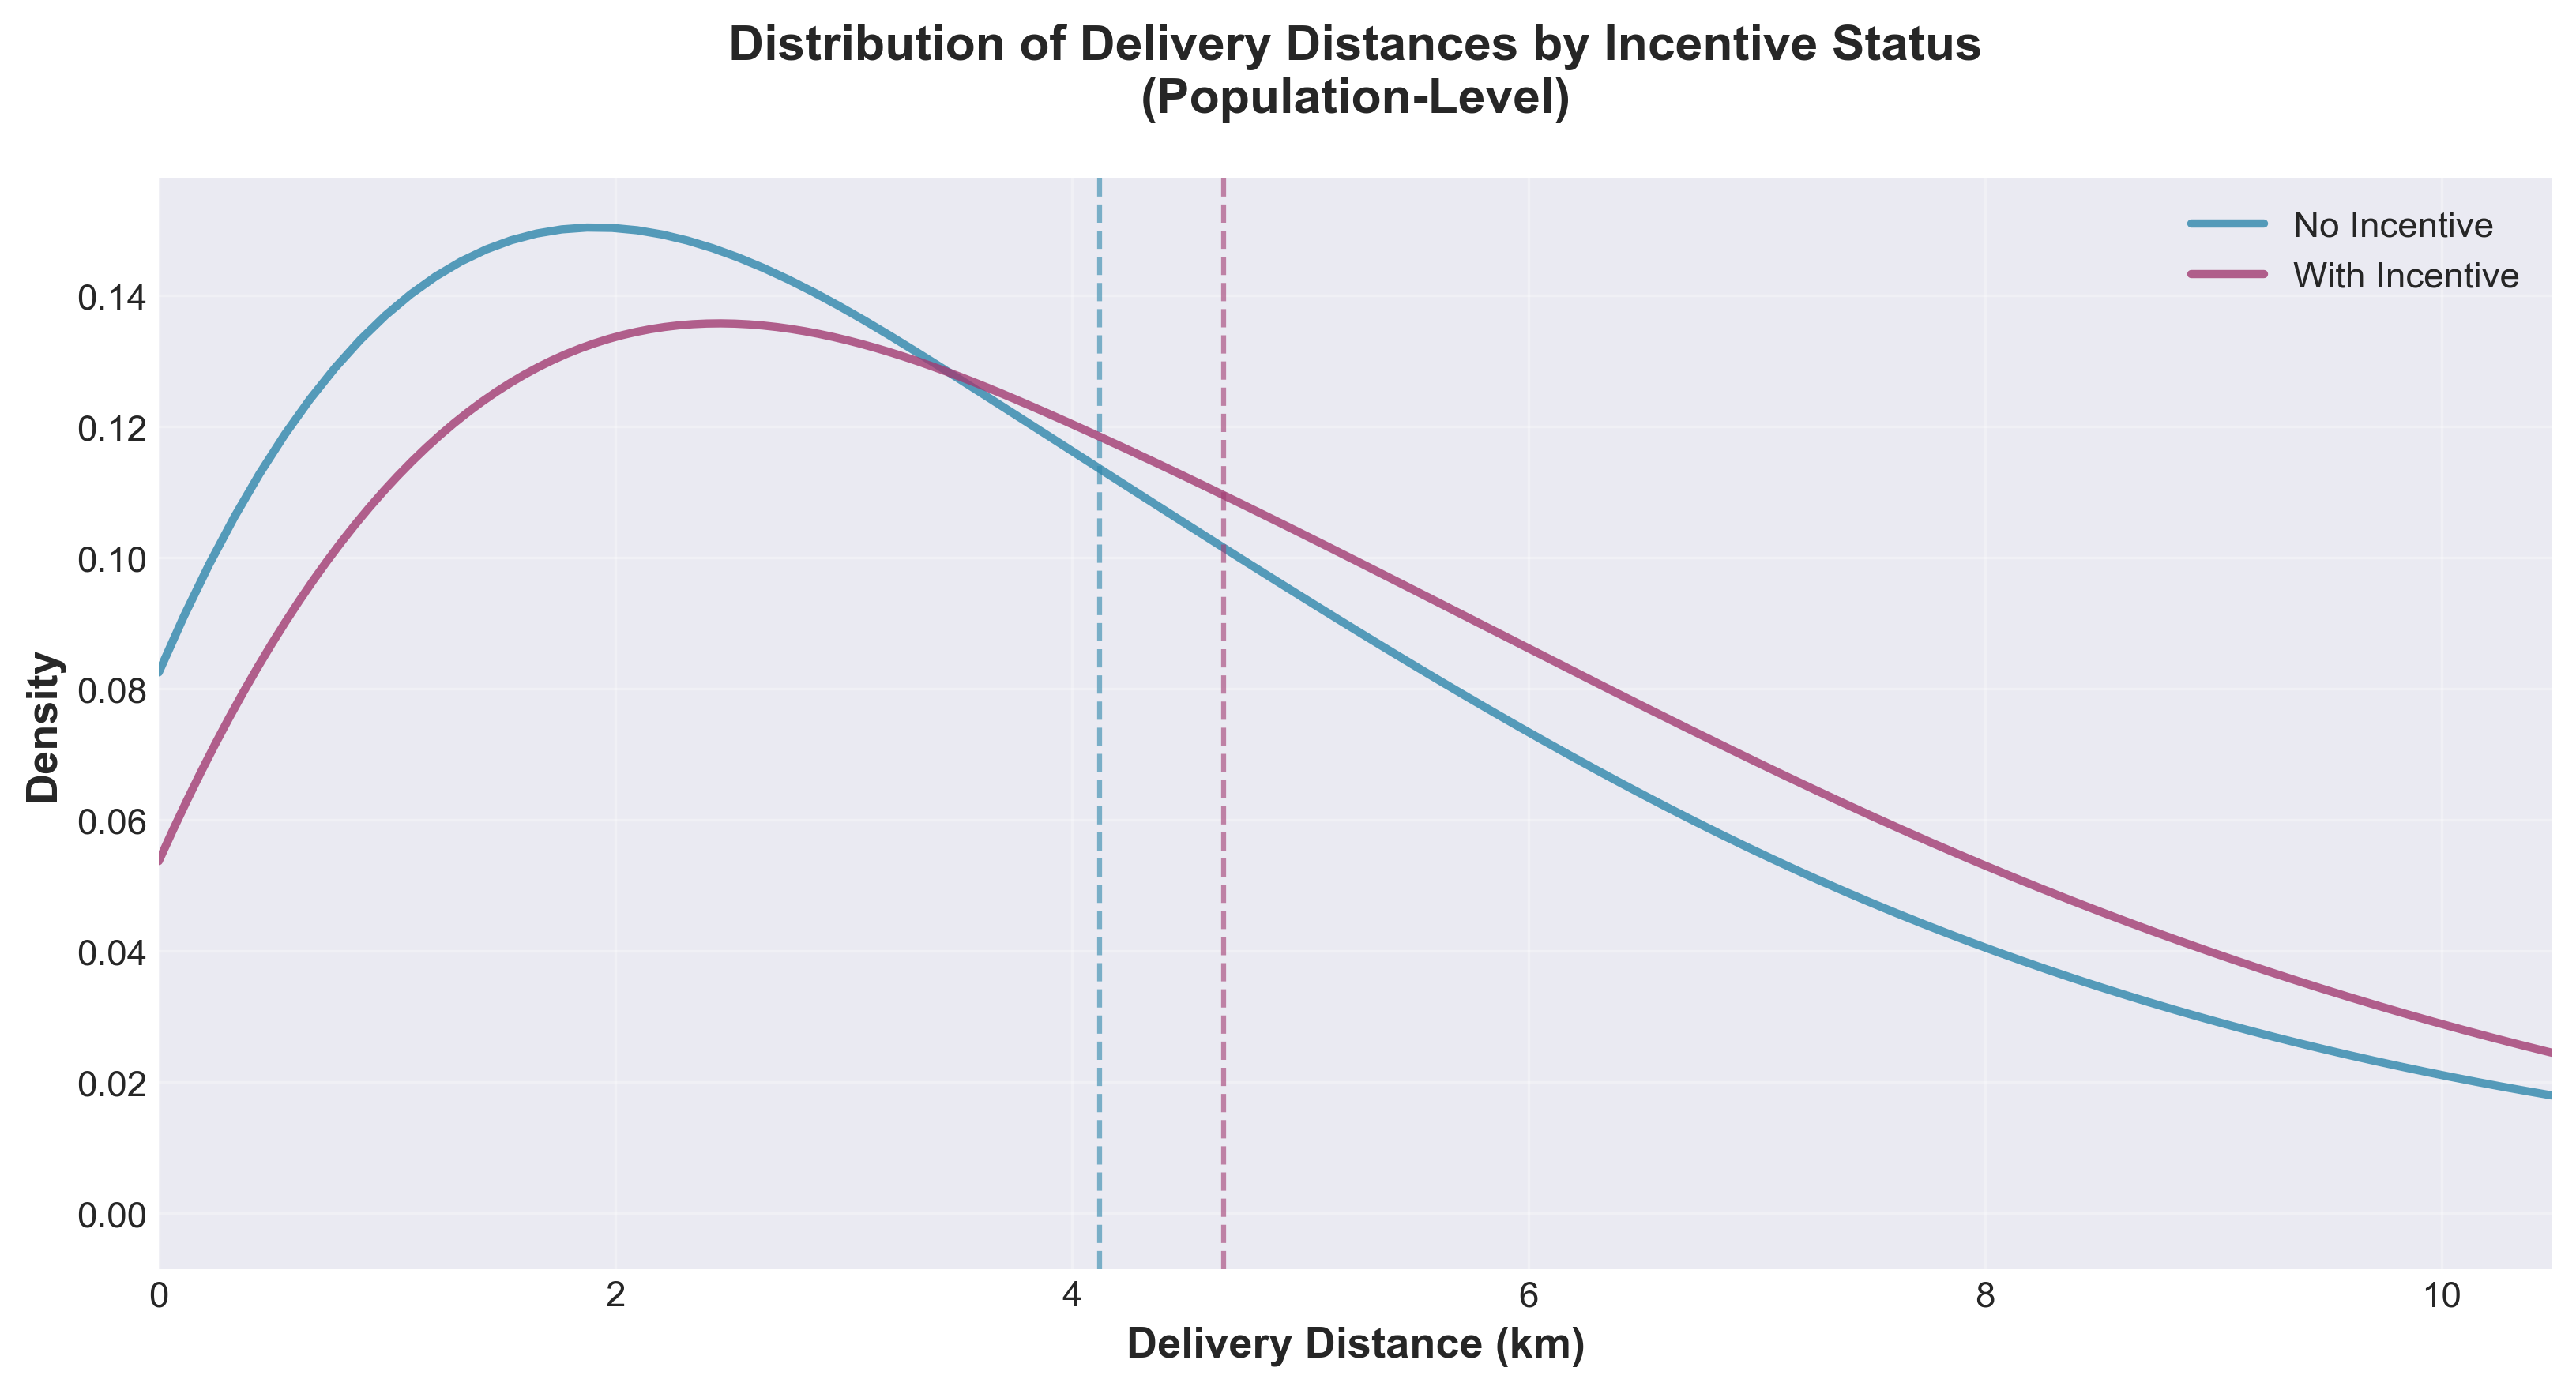

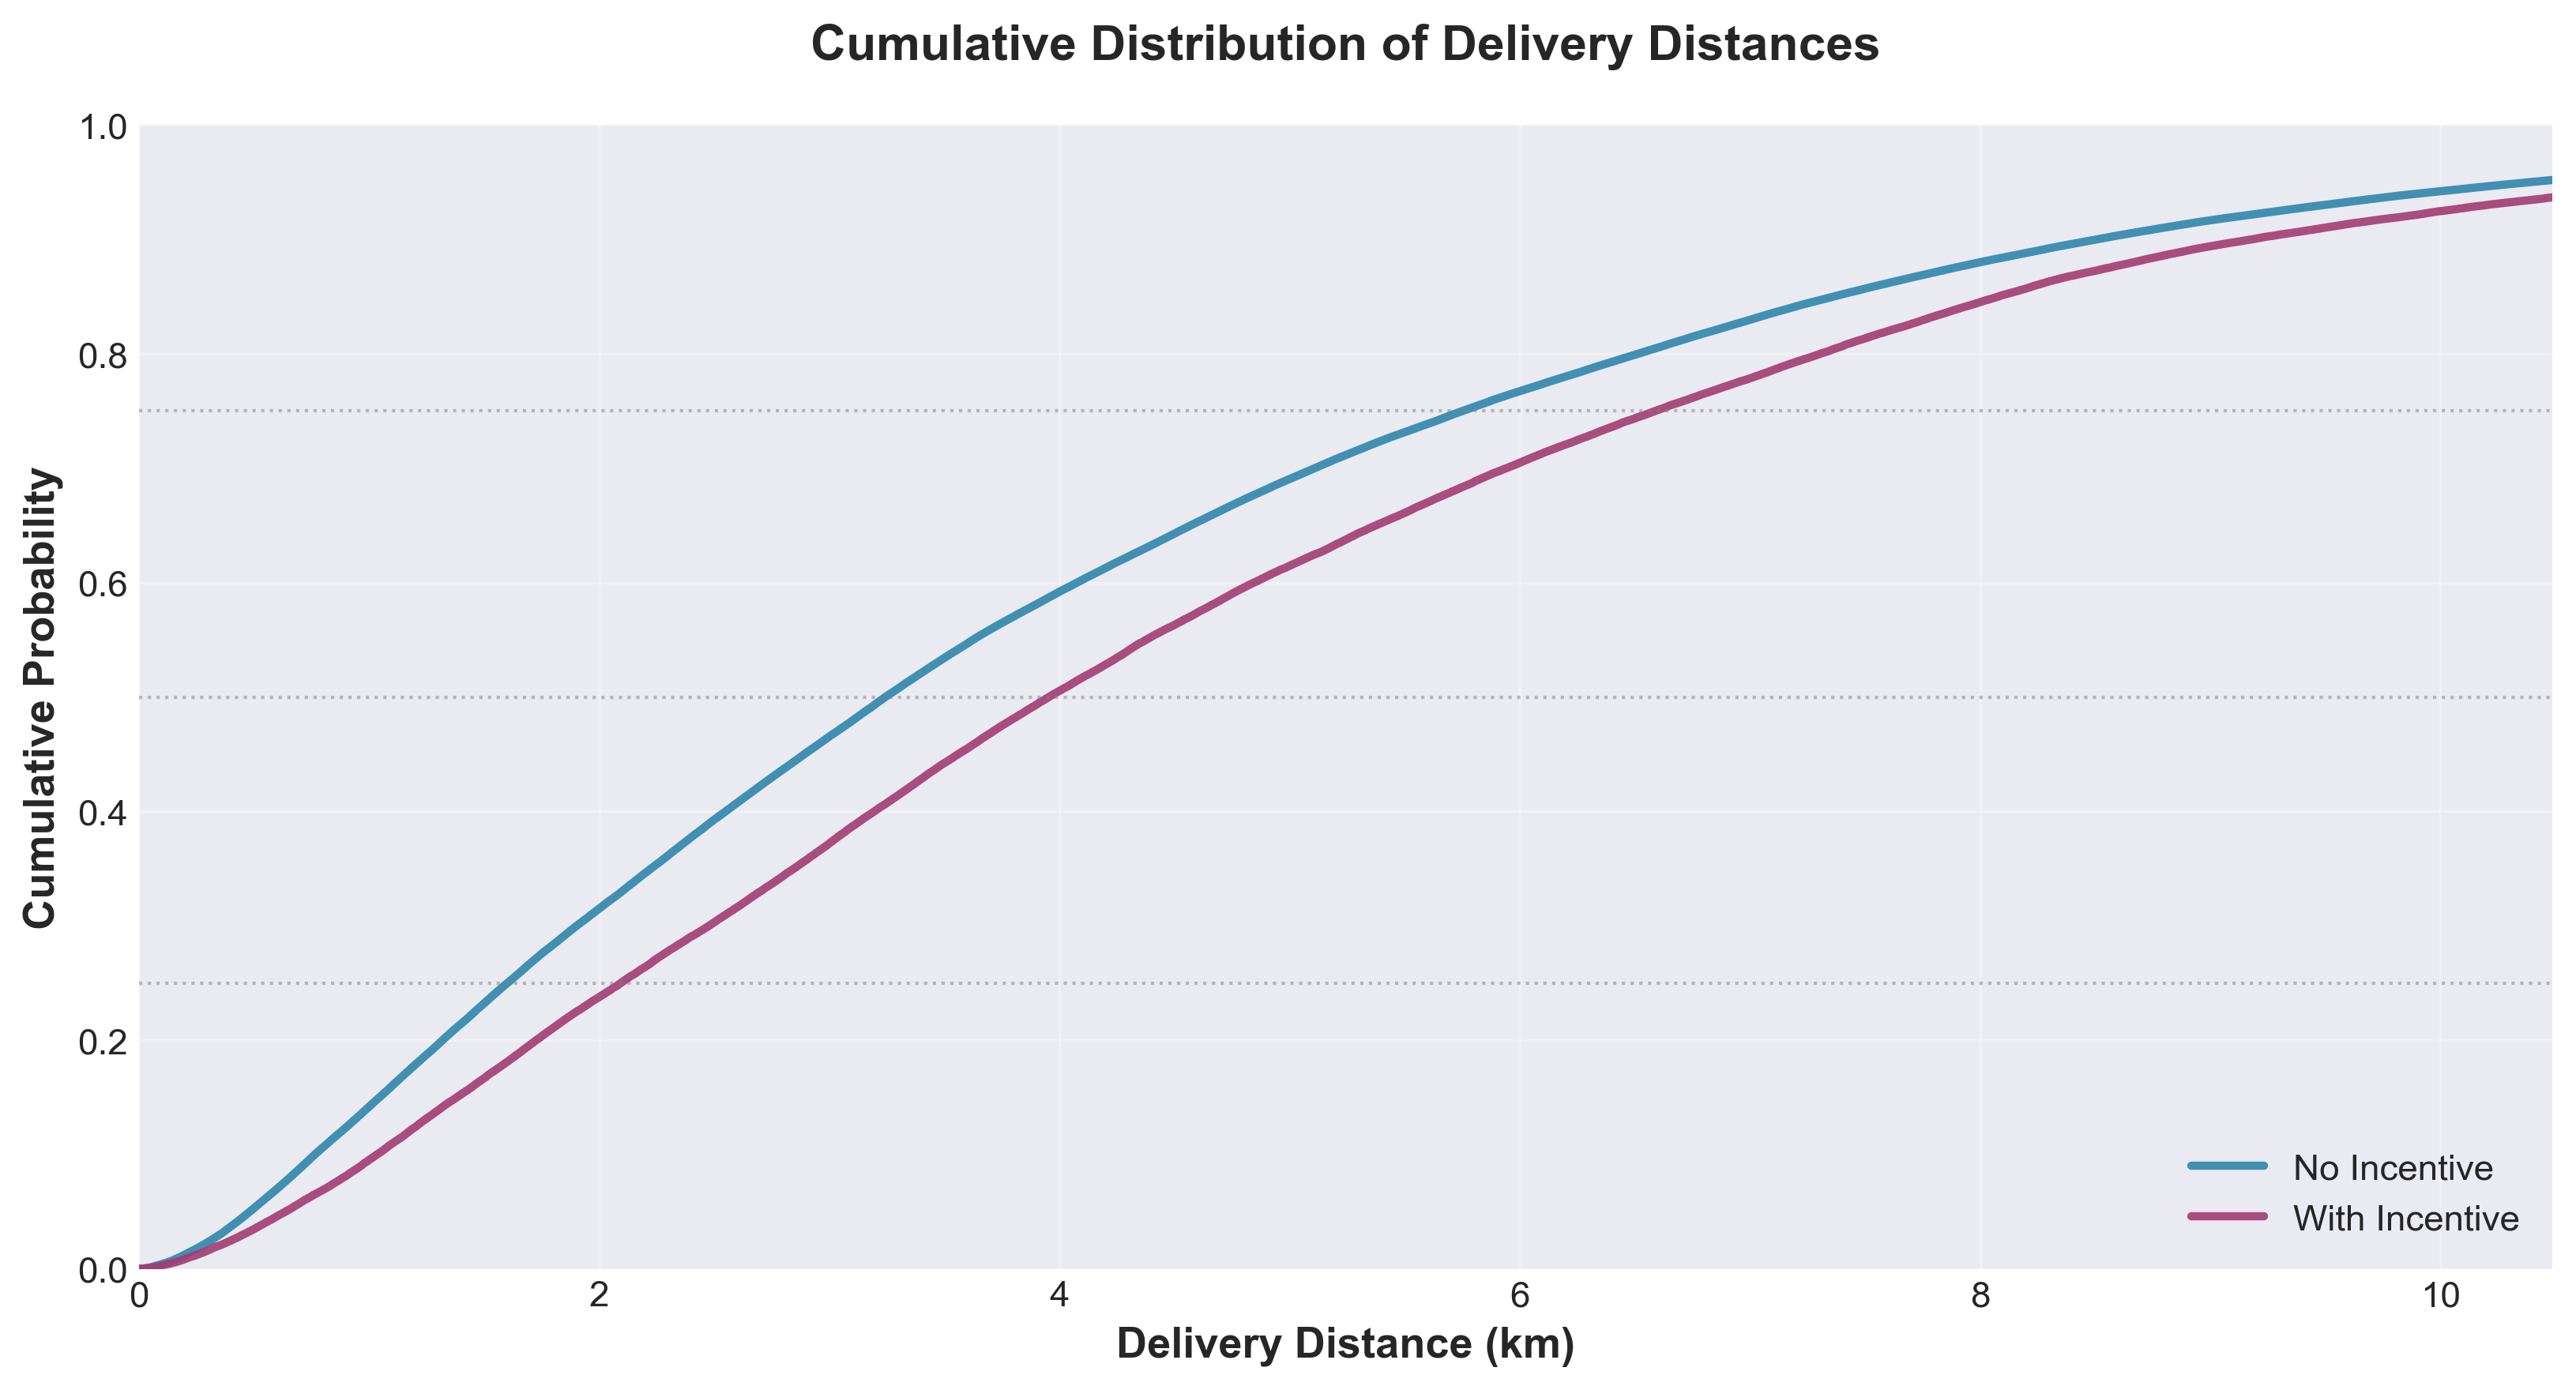

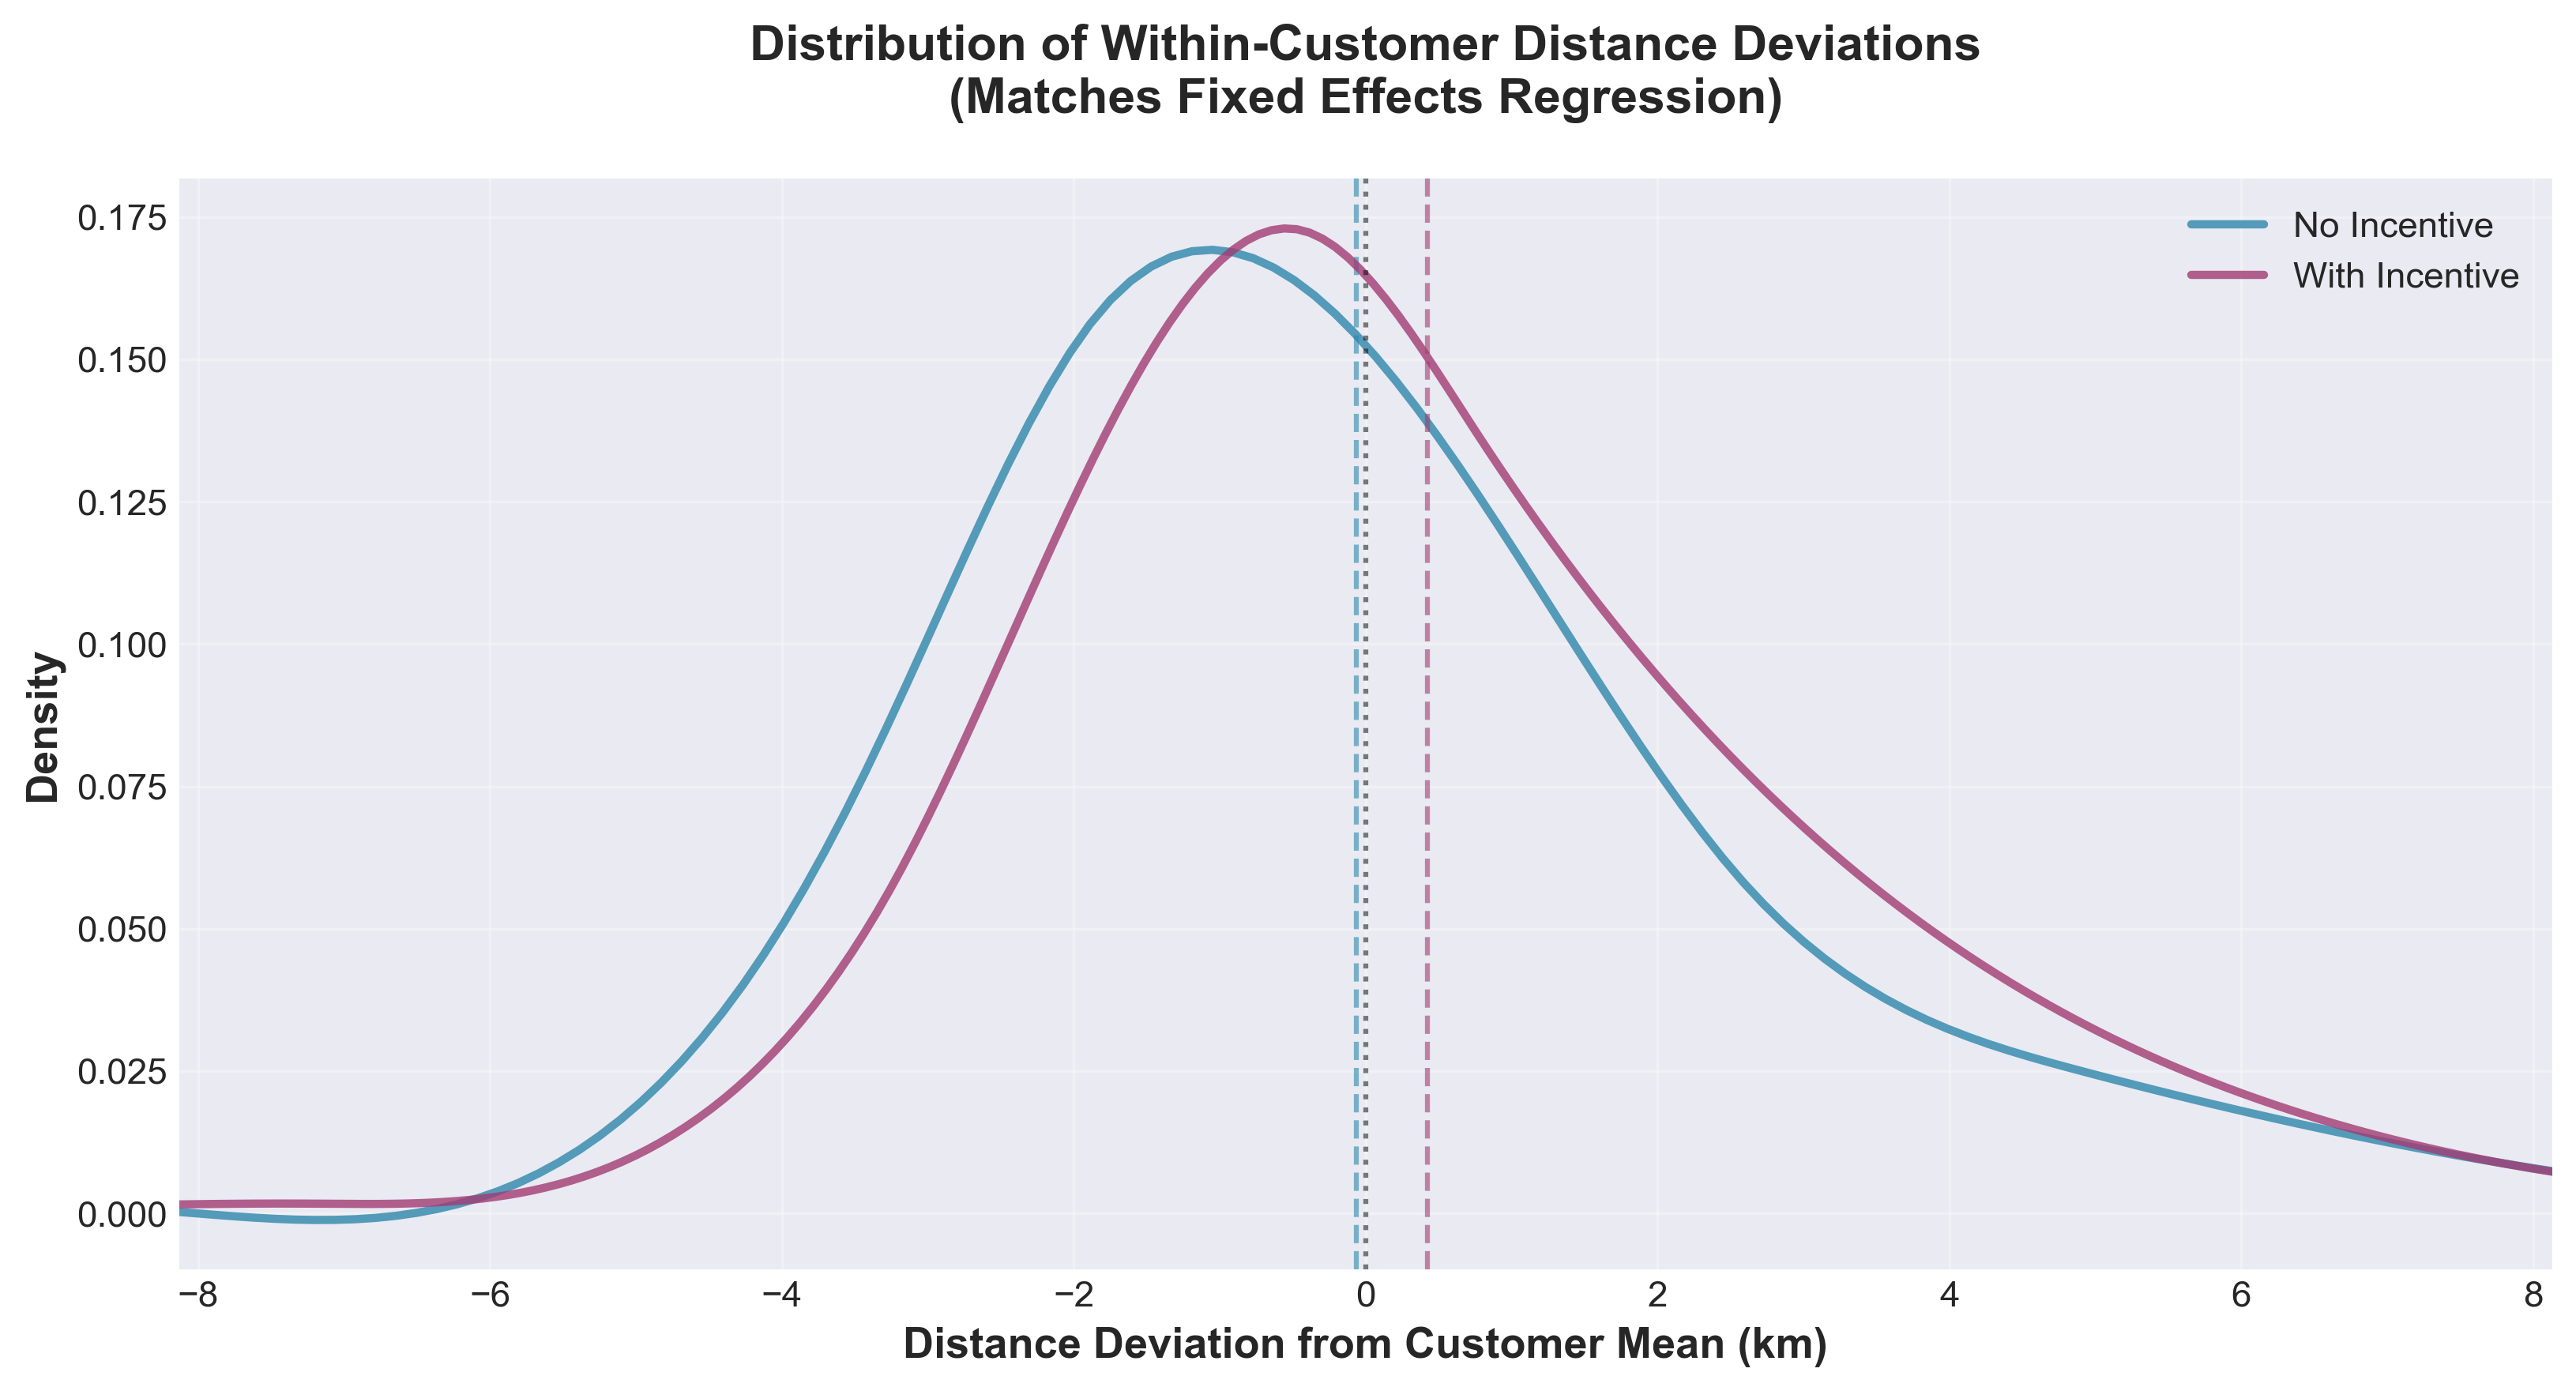

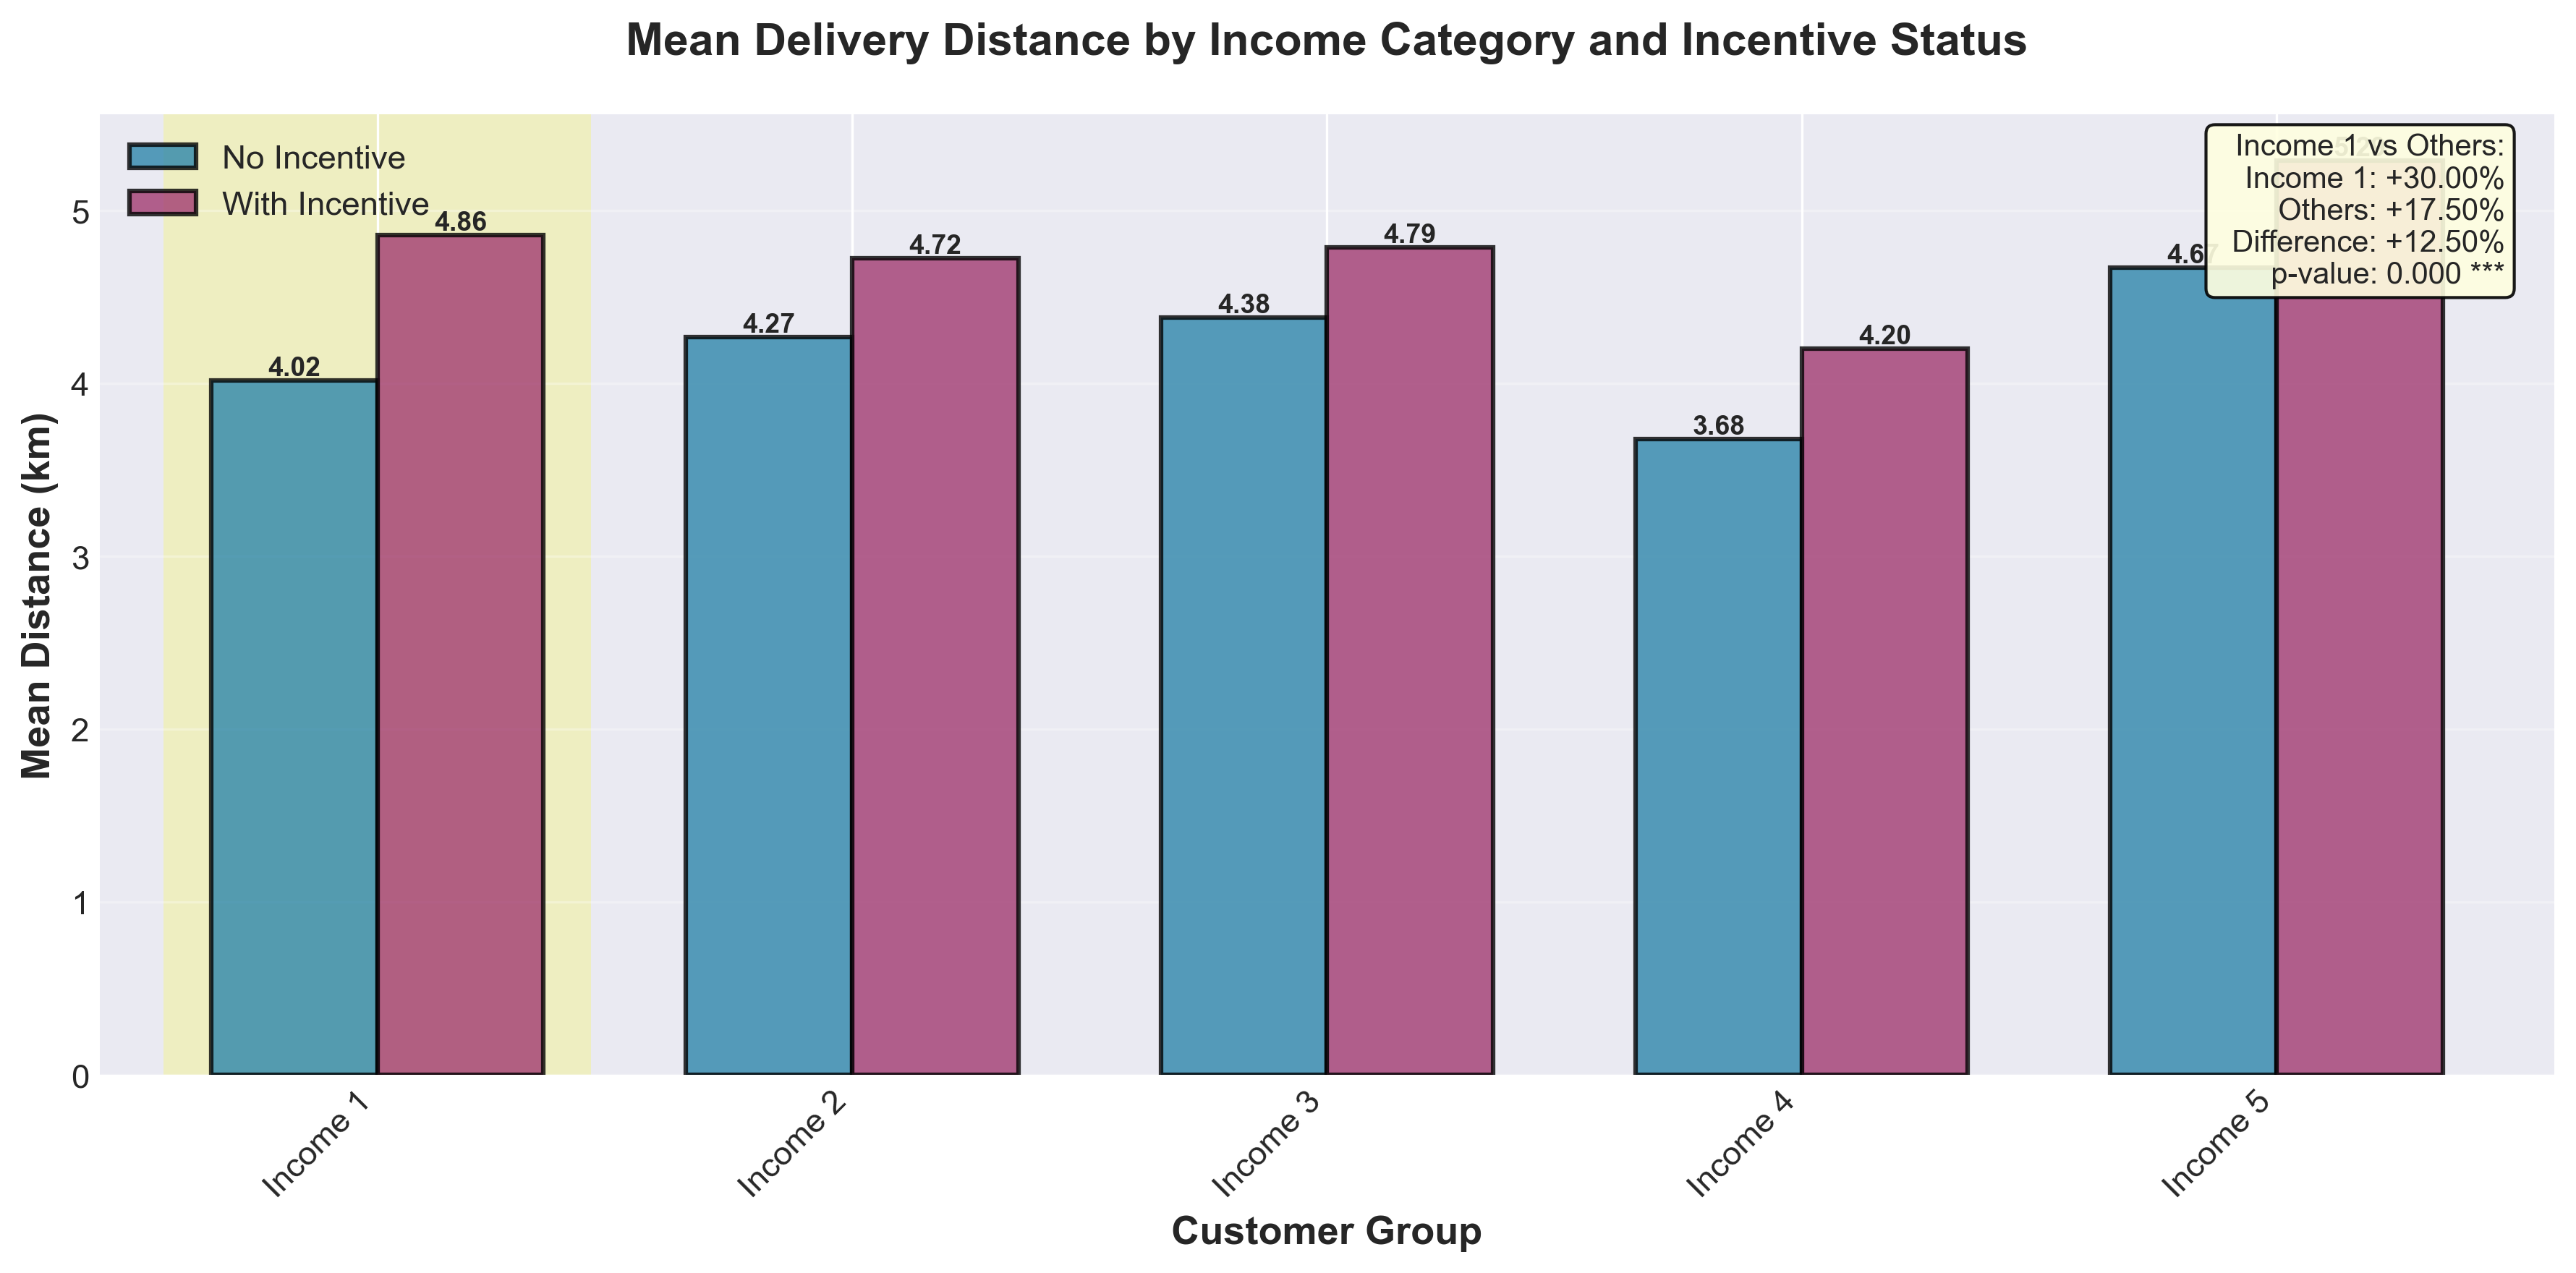

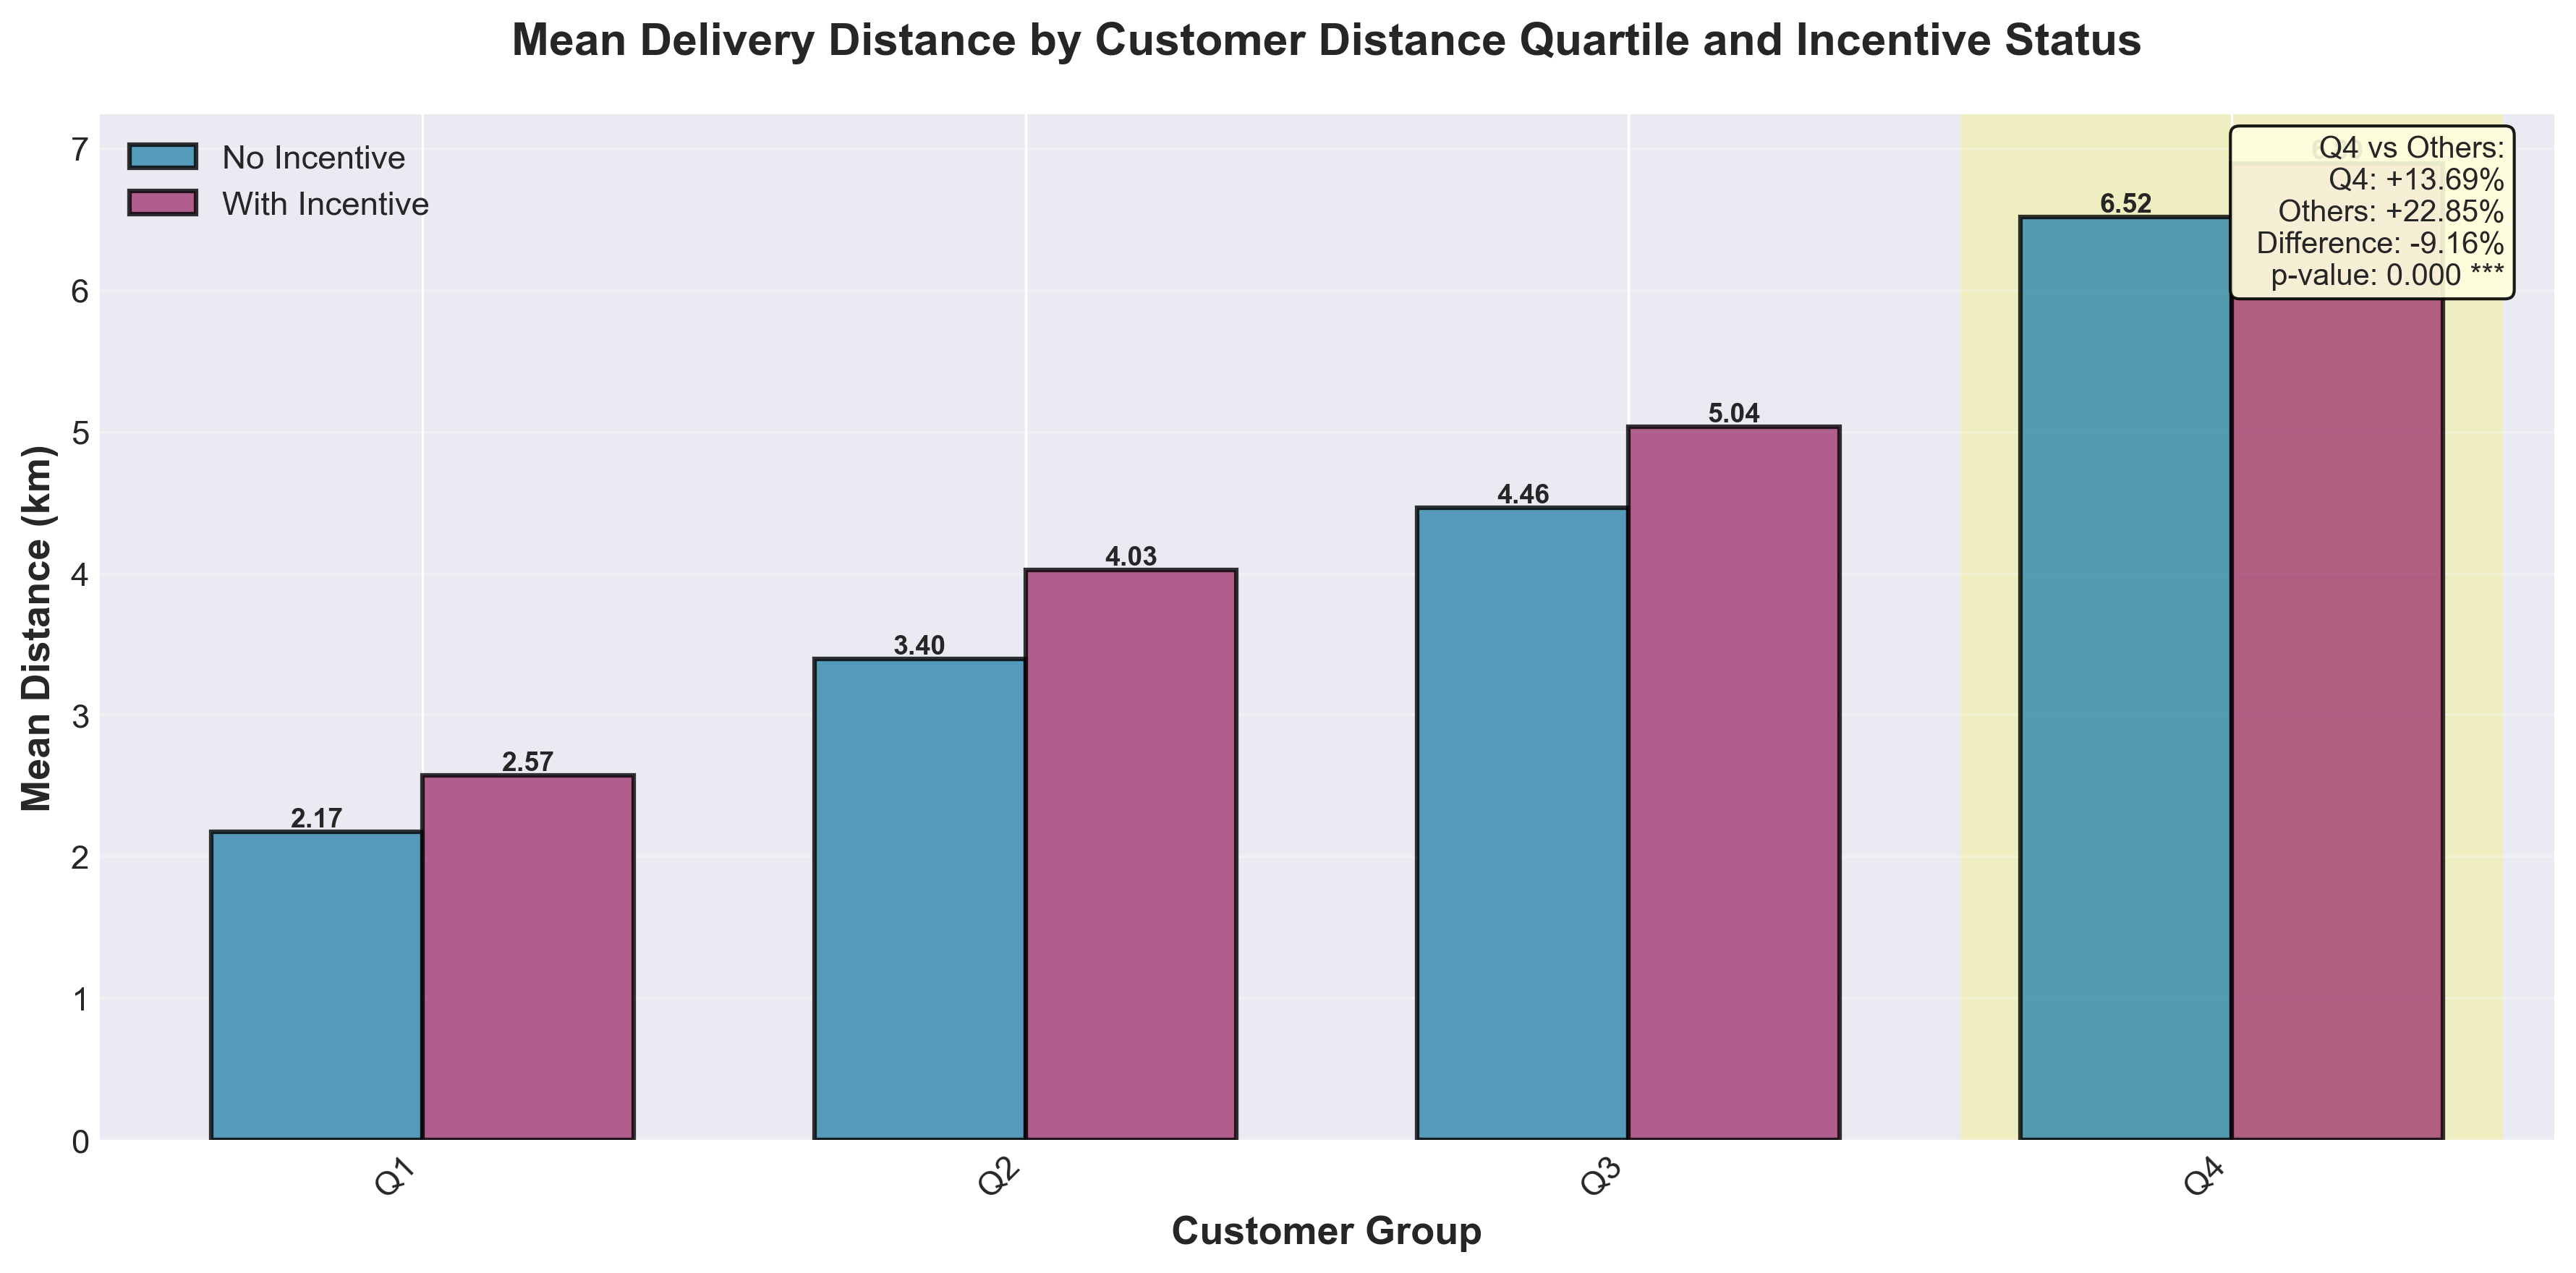

In [24]:
from scipy import stats
from linearmodels.panel import PanelOLS
import geopandas as gpd
from shapely.geometry import Point
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 11


# ============================================================================
# 1. DATA PREPROCESSING
# ============================================================================

def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 6371 * 2 * np.arcsin(np.sqrt(a))


def assign_income_category(df, gdf_income, drop_unmatched=False):
    """Spatially join customers to income polygons."""
    gdf_customers = gpd.GeoDataFrame(
        df, 
        geometry=gpd.points_from_xy(df.customer_lng, df.customer_lat),
        crs='EPSG:4326'
    )
    gdf_customers = gdf_customers.to_crs('EPSG:3857')
    
    df_merged = gpd.sjoin_nearest(gdf_customers, gdf_income[['income_category', 'geometry']], 
                                   how='left', distance_col='dist_to_polygon')
    
    if drop_unmatched:
        df_merged = df_merged[df_merged['income_category'].notna()].copy()
    else:
        df_merged['income_category'] = df_merged['income_category'].fillna(
            df_merged.groupby('account_id')['income_category'].transform(lambda x: x.mode()[0] if x.notna().any() else np.nan)
        )
    
    return df_merged.drop(columns=['geometry', 'index_right', 'dist_to_polygon']).reset_index(drop=True)


def calculate_avg_fee_per_km(df):
    """Calculate average delivery fee per km by vendor and time period."""
    df['fee_per_km'] = df['delivery_fee_amount_lc'] / df['distance_km']
    df['avg_fee_per_km'] = df.groupby(['vendor_id', 'time_period'])['fee_per_km'].transform('mean')
    return df


def prepare_data(df, gdf_income, drop_unmatched=False):
    print("="*80)
    print("DATA PREPROCESSING")
    print("="*80)
    
    df_clean = df.copy()
    
    print("\n[1/8] Calculating distances...")
    df_clean['distance_km'] = haversine_distance(
        df_clean['vendor_lat'], df_clean['vendor_lng'],
        df_clean['customer_lat'], df_clean['customer_lng']
    )
    df_clean = df_clean[df_clean['distance_km'] > 0].copy()
    print(f"   Orders: {len(df_clean):,}, Customers: {df_clean['account_id'].nunique():,}")
    
    print("\n[2/8] Creating incentive categories...")
    df_clean['incentive_cat'] = df_clean['delivery_incentive_lc'].apply(
        lambda x: 'with_incentive' if x > 0 else 'no_incentive'
    )
    print(df_clean['incentive_cat'].value_counts())
    
    print("\n[3/8] Merging income data...")
    df_clean = assign_income_category(df_clean, gdf_income, drop_unmatched)
    print(f"   Orders after merge: {len(df_clean):,}")
    print(f"   Income categories:\n{df_clean['income_category'].value_counts()}")
    
    print("\n[4/8] Calculating average fee per km control...")
    df_clean = calculate_avg_fee_per_km(df_clean)
    
    print("\n[5/8] Filtering customers with >5 orders...")
    order_counts = df_clean.groupby('account_id').size()
    customers_many = order_counts[order_counts >= 3].index ###########################################
    df_clean = df_clean[df_clean['account_id'].isin(customers_many)].copy()
    print(f"   Customers: {len(customers_many):,}, Orders: {len(df_clean):,}")
    
    print("\n[6/8] Filtering customers with incentive variation...")
    customer_variation = df_clean.groupby('account_id')['incentive_cat'].apply(lambda x: x.nunique())
    customers_variation = customer_variation[customer_variation > 1].index
    df_clean = df_clean[df_clean['account_id'].isin(customers_variation)].copy()
    print(f"   Customers with variation: {len(customers_variation):,}, Orders: {len(df_clean):,}")

    
    print("\n[7/8] Creating customer distance quartiles...")
    customer_avg_dist = df_clean.groupby('account_id')['distance_km'].mean()
    customer_quartiles = pd.qcut(customer_avg_dist, q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
    df_clean['customer_dist_quartile'] = df_clean['account_id'].map(customer_quartiles)
    print(f"   Quartile distribution:\n{df_clean['customer_dist_quartile'].value_counts().sort_index()}")


    
    print("\n[8/8] Creating variables...")
    df_clean['log_distance'] = np.log(df_clean['distance_km'])
    df_clean['log_basket'] = np.log(df_clean['basket_amount_lc'] + 1)
    df_clean['is_food'] = (df_clean['vertical_class'] == 'food').astype(int)
    df_clean['is_weekend'] = (df_clean['day_type'] == 'weekend').astype(int)
    
    # Create single dummy for incentive
    df_clean['has_incentive'] = (df_clean['incentive_cat'] == 'with_incentive').astype(int)
    
    print(f"\n   Final sample: {len(df_clean):,} orders, {df_clean['account_id'].nunique():,} customers")
    print(f"   Mean distance: {df_clean['distance_km'].mean():.2f} km")
    
    return df_clean


# ============================================================================
# 2. ESTIMATION
# ============================================================================

def estimate_model(df, controls=True, subset_filter=None, subset_name="Full Sample"):
    """Estimate fixed effects model with optional controls and subset filtering."""
    
    df_model = df.copy()
    if subset_filter is not None:
        df_model = df_model[subset_filter].copy()
    
    # Base specification
    formula = 'log_distance ~ has_incentive'
    
    # Add controls if requested
    if controls:
        control_vars = [
            'log_basket',
            'avg_fee_per_km',
            'is_food',
            'is_weekend',
            'C(time_period)',
            'C(quarter)'
        ]
        formula += ' + ' + ' + '.join(control_vars)
    
    formula += ' + EntityEffects'
    
    df_panel = df_model.set_index(['account_id', df_model.groupby('account_id').cumcount()])
    
    model = PanelOLS.from_formula(formula, data=df_panel)
    results = model.fit(cov_type='clustered', cluster_entity=True)
    
    # Extract key results
    coef = results.params.get('has_incentive', np.nan)
    se = results.std_errors.get('has_incentive', np.nan)
    pval = results.pvalues.get('has_incentive', np.nan)
    
    pct_change = (np.exp(coef) - 1) * 100 if not np.isnan(coef) else np.nan
    
    summary = {
        'subset': subset_name,
        'n_obs': results.nobs,
        'n_customers': results.entity_info['total'],
        'coef': coef,
        'se': se,
        'pval': pval,
        'pct_change': pct_change,
        'r2': results.rsquared,
        'r2_within': results.rsquared_within
    }
    
    # NEW: Export results to CSV
    _export_results_to_csv(results, subset_name)
    
    return results, summary


def run_baseline_analysis(df):
    """Run main regression analysis."""
    print("\n" + "="*80)
    print("BASELINE ESTIMATION")
    print("="*80)
    
    results, summary = estimate_model(df, controls=True)
    
    print(f"\nSample: {summary['n_obs']:,.0f} orders, {summary['n_customers']:,.0f} customers")
    print(f"\nIncentive Effect:")
    print(f"  Coefficient: {summary['coef']:.4f} (SE: {summary['se']:.4f})")
    print(f"  P-value: {summary['pval']:.4f}")
    print(f"  Impact: {summary['pct_change']:+.2f}% change in distance")
    print(f"\nR-squared (within): {summary['r2_within']:.4f}")
    
    return results, summary


def _export_results_to_csv(results, model_name="model", output_path='~/imperial/Reach of Last Mile/'):
    """
    Internal helper function to export regression results to CSV.
    Called automatically by estimate_model().
    """
    
    # Extract coefficients with significance
    coef_data = []
    for var in results.params.index:
        coef = results.params[var]
        se = results.std_errors[var]
        tstat = results.tstats[var]
        pval = results.pvalues[var]
        
        # Add significance stars
        if pval < 0.001:
            sig = '***'
        elif pval < 0.01:
            sig = '**'
        elif pval < 0.05:
            sig = '*'
        else:
            sig = ''
        
        coef_data.append({
            'variable': var,
            'coefficient': coef,
            'std_error': se,
            't_statistic': tstat,
            'p_value': pval,
            'significance': sig
        })
    
    coef_df = pd.DataFrame(coef_data)
    
    # Extract model statistics
    stats_data = {
        'model_name': [model_name],
        'N_observations': [results.nobs],
        'N_entities': [results.entity_info['total']],
        'R_squared': [results.rsquared],
        'R_squared_within': [results.rsquared_within],
        'R_squared_between': [results.rsquared_between],
        'R_squared_overall': [results.rsquared_overall],
        'F_statistic': [results.f_statistic.stat if hasattr(results.f_statistic, 'stat') else np.nan],
        'F_pvalue': [results.f_statistic.pval if hasattr(results.f_statistic, 'pval') else np.nan]
    }
    stats_df = pd.DataFrame(stats_data)
    
    # Save to CSV
    coef_file = output_path + 'regression_coefficients.csv'
    stats_file = output_path + 'regression_stats.csv'
    
    coef_df.to_csv(coef_file, index=False)
    stats_df.to_csv(stats_file, index=False)
    
    print(f"\n[CSV Export] Results saved to:")
    print(f"  - {coef_file}")
    print(f"  - {stats_file}")
    
    return coef_df, stats_df


# ============================================================================
# 3. PLOTTING
# ============================================================================

def plot_density_three_groups(df, xlim=None):
    """Density plot for two incentive categories with spline smoothing."""
    from scipy.interpolate import UnivariateSpline
    
    fig, ax = plt.subplots(figsize=(11, 6))
    
    colors = {'no_incentive': '#2E86AB', 'with_incentive': '#A23B72'}
    labels = {'no_incentive': 'No Incentive', 'with_incentive': 'With Incentive'}
    
    for cat in ['no_incentive', 'with_incentive']:
        data = df[df['incentive_cat'] == cat]['distance_km'].values
        if len(data) > 0:
            # Get KDE estimates
            from scipy.stats import gaussian_kde
            kde = gaussian_kde(data, bw_method=0.2)
            
            # Create smooth x values
            x_min, x_max = data.min(), data.max()
            x_eval = np.linspace(x_min, x_max, 1000)
            y_eval = kde(x_eval)
            
            # Apply spline interpolation for extra smoothness
            spline = UnivariateSpline(x_eval, y_eval, s=0.001, k=3)
            x_smooth = np.linspace(x_min, x_max, 2000)
            y_smooth = spline(x_smooth)
            
            ax.plot(x_smooth, y_smooth, linewidth=2.5, label=labels[cat],
                   color=colors[cat], alpha=0.8)
            
            mean_val = data.mean()
            ax.axvline(mean_val, color=colors[cat], linestyle='--', linewidth=1.5, alpha=0.6)
    
    ax.set_xlabel('Delivery Distance (km)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Density', fontsize=13, fontweight='bold')
    ax.set_title('Distribution of Delivery Distances by Incentive Status\n(Population-Level)', 
                 fontsize=15, fontweight='bold', pad=20)
    if xlim:
        ax.set_xlim(xlim)
    ax.legend(loc='upper right', framealpha=0.95)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, ax


def plot_within_customer_density(df, xlim=None, curve_output_path="./grouped_exports/within_customer_curves.csv"):
    """Density plot of demeaned distances (within-customer variation),
    and saves the smoothed curves for later plotting in R."""

    from scipy.interpolate import UnivariateSpline
    from scipy.stats import gaussian_kde
    import pandas as pd

    # # Demean distances within each customer
    df_plot = df.copy()
    df_plot['distance_demeaned'] = df_plot.groupby('account_id')['distance_km'].transform(
        lambda x: x - x.mean()
    )
    
    fig, ax = plt.subplots(figsize=(11, 6))

    colors = {'no_incentive': '#2E86AB', 'with_incentive': '#A23B72'}
    labels = {'no_incentive': 'No Incentive', 'with_incentive': 'With Incentive'}

    # To store R-ready curves
    curve_list = []

    for cat in ['no_incentive', 'with_incentive']:
        data = df_plot[df_plot['incentive_cat'] == cat]['distance_demeaned'].values
        if len(data) > 0:

            kde = gaussian_kde(data, bw_method=0.2)
            x_min, x_max = data.min(), data.max()

            x_eval = np.linspace(x_min, x_max, 1000)
            y_eval = kde(x_eval)

            spline = UnivariateSpline(x_eval, y_eval, s=0.001, k=3)
            x_smooth = np.linspace(x_min, x_max, 2000)
            y_smooth = spline(x_smooth)

            # ---- SAVE CURVE POINTS ----
            curve_df = pd.DataFrame({
                "incentive_cat": cat,
                "x": x_smooth,
                "y": y_smooth
            })
            curve_list.append(curve_df)

            # ---- PLOT ----
            ax.plot(
                x_smooth, y_smooth, linewidth=2.5,
                label=labels[cat], color=colors[cat], alpha=0.8
            )

            ax.axvline(data.mean(), color=colors[cat], linestyle='--',
                       linewidth=1.5, alpha=0.6)
    
    # Save curves as a single CSV
    if len(curve_list) > 0:
        full_curve_df = pd.concat(curve_list, ignore_index=True)
        full_curve_df.to_csv(curve_output_path, index=False)
        print(f"Saved curves to: {curve_output_path}")

    # Static elements
    ax.axvline(0, color='black', linestyle=':', linewidth=1.5, alpha=0.5)
    ax.set_xlabel('Distance Deviation from Customer Mean (km)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Density', fontsize=13, fontweight='bold')
    ax.set_title(
        'Distribution of Within-Customer Distance Deviations\n(Matches Fixed Effects Regression)',
        fontsize=15, fontweight='bold', pad=20
    )

    if xlim:
        ax.set_xlim(xlim)

    ax.legend(loc='upper right', framealpha=0.95)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    return fig, ax


def plot_cdf_three_groups(df, xlim=None):
    """CDF plot for two incentive categories with smoother curves."""
    from scipy.ndimage import gaussian_filter1d
    
    fig, ax = plt.subplots(figsize=(11, 6))
    
    colors = {'no_incentive': '#2E86AB', 'with_incentive': '#A23B72'}
    labels = {'no_incentive': 'No Incentive', 'with_incentive': 'With Incentive'}
    
    for cat in ['no_incentive', 'with_incentive']:
        data = np.sort(df[df['incentive_cat'] == cat]['distance_km'].values)
        if len(data) > 0:
            # Use moderate points for smooth curve
            n_points = min(10000, len(data))
            if len(data) > n_points:
                indices = np.linspace(0, len(data)-1, n_points, dtype=int)
                x_plot = data[indices]
                y_plot = (indices + 1) / len(data)
            else:
                x_plot = data
                y_plot = np.arange(1, len(data) + 1) / len(data)
            
            # Apply Gaussian smoothing
            y_smooth = gaussian_filter1d(y_plot, sigma=2)
            
            ax.plot(x_plot, y_smooth, linewidth=2.5, label=labels[cat], 
                   color=colors[cat], alpha=0.9)
    
    for p in [0.25, 0.5, 0.75]:
        ax.axhline(y=p, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    
    ax.set_xlabel('Delivery Distance (km)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Cumulative Probability', fontsize=13, fontweight='bold')
    ax.set_title('Cumulative Distribution of Delivery Distances', 
                 fontsize=15, fontweight='bold', pad=20)
    if xlim:
        ax.set_xlim(xlim)
    ax.set_ylim(0, 1)
    ax.legend(loc='lower right', framealpha=0.95)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, ax


def create_main_plots(df):
    """Generate main visualization plots."""
    print("\n" + "="*80)
    print("CREATING MAIN PLOTS")
    print("="*80)
    
    xlim = (0, df['distance_km'].quantile(0.95))
    
    print("\n[1/2] Density plot...")
    fig1, ax1 = plot_density_three_groups(df, xlim)
    
    print("[2/2] CDF plot...")
    fig2, ax2 = plot_cdf_three_groups(df, xlim)
    
    print("\n✓ Main plots created")
    return fig1, fig2


# ============================================================================
# 4. HETEROGENEITY ANALYSIS
# ============================================================================

def calculate_group_means(df, group_col, group_values):
    """Calculate mean distances by incentive category for each group."""
    results_list = []
    
    for group_val in group_values:
        subset = df[df[group_col] == group_val]
        
        mean_no_incentive = subset[subset['incentive_cat'] == 'no_incentive']['distance_km'].mean()
        mean_with_incentive = subset[subset['incentive_cat'] == 'with_incentive']['distance_km'].mean()
        n_obs = len(subset)
        
        results_list.append({
            'group': group_val,
            'mean_no_incentive': mean_no_incentive,
            'mean_with_incentive': mean_with_incentive,
            'n_obs': n_obs
        })
    
    return pd.DataFrame(results_list)


def run_heterogeneity_by_income(df):
    """Run separate regressions by income category."""
    print("\n" + "="*80)
    print("HETEROGENEITY ANALYSIS: INCOME")
    print("="*80)
    
    results_list = []
    income_cats = sorted(df['income_category'].dropna().unique())
    
    for inc_cat in income_cats:
        print(f"\n--- Income Category {inc_cat} ---")
        subset_filter = df['income_category'] == inc_cat
        _, summary = estimate_model(df, controls=True, subset_filter=subset_filter, 
                                    subset_name=f"Income {inc_cat}")
        results_list.append(summary)
        print(f"N={summary['n_obs']:,.0f}, Effect: {summary['pct_change']:+.2f}%")
    
    df_results = pd.DataFrame(results_list)
    
    # Calculate mean distances for bar charts
    df_means = calculate_group_means(df, 'income_category', income_cats)
    df_means['group'] = 'Income ' + df_means['group'].astype(str)
    
    return df_results, df_means


def run_heterogeneity_by_distance(df):
    """Run separate regressions by customer distance quartile."""
    print("\n" + "="*80)
    print("HETEROGENEITY ANALYSIS: DISTANCE QUARTILES")
    print("="*80)
    
    results_list = []
    quartiles = ['Q1', 'Q2', 'Q3', 'Q4']
    
    for q in quartiles:
        print(f"\n--- {q} ---")
        subset_filter = df['customer_dist_quartile'] == q
        _, summary = estimate_model(df, controls=True, subset_filter=subset_filter, 
                                    subset_name=q)
        results_list.append(summary)
        print(f"N={summary['n_obs']:,.0f}, Effect: {summary['pct_change']:+.2f}%")
    
    df_results = pd.DataFrame(results_list)
    
    # Calculate mean distances for bar charts
    df_means = calculate_group_means(df, 'customer_dist_quartile', quartiles)
    
    return df_results, df_means


def plot_grouped_bars_sidebyside(df_means, group_col='group', title='', 
                                  output_path=None, highlight_groups=None, comparison_text=None):
    """Bar chart showing side-by-side bars for with/without incentive in each group."""
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    groups = df_means[group_col].values
    x = np.arange(len(groups))
    width = 0.35
    
    # Colors for the two conditions
    color_no = '#2E86AB'
    color_with = '#A23B72'
    
    bars1 = ax.bar(x - width/2, df_means['mean_no_incentive'], width, 
                   label='No Incentive', color=color_no, alpha=0.8, edgecolor='black', linewidth=1.5)
    bars2 = ax.bar(x + width/2, df_means['mean_with_incentive'], width,
                   label='With Incentive', color=color_with, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    ax.set_xlabel('Customer Group', fontsize=13, fontweight='bold')
    ax.set_ylabel('Mean Distance (km)', fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=45, ha='right')
    ax.legend(loc='upper left', framealpha=0.95)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}', ha='center', va='bottom',
                   fontsize=9, fontweight='bold')
    
    # Highlight specific groups if requested
    if highlight_groups:
        for i, g in enumerate(groups):
            if g in highlight_groups:
                # Add a rectangle behind the bars
                rect = plt.Rectangle((i - 0.45, ax.get_ylim()[0]), 0.9, ax.get_ylim()[1] - ax.get_ylim()[0],
                                    facecolor='yellow', alpha=0.2, zorder=0)
                ax.add_patch(rect)
    
    # Add comparison text box if provided
    if comparison_text:
        ax.text(0.98, 0.98, comparison_text, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='black'))
    
    plt.tight_layout()
    
    # Save data for R if path provided
    if output_path:
        df_means.to_csv(output_path, index=False)
        print(f"Saved bar chart data to: {output_path}")
    
    return fig, ax


def test_coefficient_difference(df_results, target_group, group_col='subset'):
    """Test if target group coefficient differs significantly from others."""
    
    target_row = df_results[df_results[group_col] == target_group].iloc[0]
    others_rows = df_results[df_results[group_col] != target_group]
    
    # Target group stats
    coef_target = target_row['coef']
    se_target = target_row['se']
    
    # Average of other groups (weighted by inverse variance)
    weights = 1 / (others_rows['se'] ** 2)
    coef_others = np.average(others_rows['coef'], weights=weights)
    se_others = np.sqrt(1 / weights.sum())
    
    # T-test for difference
    diff = coef_target - coef_others
    se_diff = np.sqrt(se_target**2 + se_others**2)
    t_stat = diff / se_diff
    
    # Two-tailed p-value (approximate with normal distribution)
    from scipy.stats import norm
    p_val = 2 * (1 - norm.cdf(abs(t_stat)))
    
    pct_target = (np.exp(coef_target) - 1) * 100
    pct_others = (np.exp(coef_others) - 1) * 100
    
    return {
        'target_group': target_group,
        'target_pct': pct_target,
        'others_pct': pct_others,
        'difference': pct_target - pct_others,
        't_stat': t_stat,
        'p_value': p_val,
        'significant': p_val < 0.05
    }


def format_comparison_text(test_result):
    """Format test results into text for plot annotation."""
    
    sig_marker = '***' if test_result['p_value'] < 0.01 else '**' if test_result['p_value'] < 0.05 else '*' if test_result['p_value'] < 0.10 else ''
    
    text = f"{test_result['target_group']} vs Others:\n"
    text += f"  {test_result['target_group']}: {test_result['target_pct']:+.2f}%\n"
    text += f"  Others: {test_result['others_pct']:+.2f}%\n"
    text += f"  Difference: {test_result['difference']:+.2f}%\n"
    text += f"  p-value: {test_result['p_value']:.3f} {sig_marker}"
    
    return text


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    print("\n" + "="*80)
    print("DELIVERY DISTANCE ANALYSIS WITH HETEROGENEITY")
    print("="*80)
    
    # Check data
    try:
        dubai_df
        gdf_webmerc
        print(f"\n✓ Data loaded: {len(dubai_df):,} orders")
        print(f"✓ Income polygons loaded: {len(gdf_webmerc)} categories")
    except NameError as e:
        print(f"\nERROR: {e}")
        print("\nPlease load data first:")
        print("  >>> dubai_df = pd.read_csv('your_data.csv')")
        print("  >>> gdf_webmerc = gpd.read_file('income_polygons.shp')")
        exit()
    
    # 1. Preprocess
    df_analysis = prepare_data(dubai_df, gdf_webmerc, drop_unmatched=False)
    
    # 2. Baseline estimation
    results_baseline, summary_baseline = run_baseline_analysis(df_analysis)
    
    # 3. Main plots
    fig_density, fig_cdf = create_main_plots(df_analysis)
    
    # 3b. Within-customer plots (matches regression)
    print("\n" + "="*80)
    print("CREATING WITHIN-CUSTOMER PLOTS")
    print("="*80)
    
    print("\n[1/1] Within-customer density plot...")
    xlim_within = (-df_analysis['distance_km'].std()*2, df_analysis['distance_km'].std()*2)
    fig_within_density = plot_within_customer_density(df_analysis, xlim=xlim_within)
    
    # 4. Heterogeneity analysis
    df_income_results, df_income_means = run_heterogeneity_by_income(df_analysis)
    df_distance_results, df_distance_means = run_heterogeneity_by_distance(df_analysis)
    
    # 5. Statistical tests for heterogeneity
    print("\n" + "="*80)
    print("STATISTICAL TESTS FOR HETEROGENEITY")
    print("="*80)
    
    print("\n[1/2] Testing Income Group 1 vs Others...")
    income_test = test_coefficient_difference(df_income_results, 'Income 1')
    print(f"   Income 1 effect: {income_test['target_pct']:+.2f}%")
    print(f"   Other incomes effect: {income_test['others_pct']:+.2f}%")
    print(f"   Difference: {income_test['difference']:+.2f}%")
    print(f"   P-value: {income_test['p_value']:.4f} {'(Significant)' if income_test['significant'] else '(Not significant)'}")
    
    print("\n[2/2] Testing Distance Q4 vs Others...")
    distance_test = test_coefficient_difference(df_distance_results, 'Q4')
    print(f"   Q4 effect: {distance_test['target_pct']:+.2f}%")
    print(f"   Q1-Q3 effect: {distance_test['others_pct']:+.2f}%")
    print(f"   Difference: {distance_test['difference']:+.2f}%")
    print(f"   P-value: {distance_test['p_value']:.4f} {'(Significant)' if distance_test['significant'] else '(Not significant)'}")
    
    # 6. Heterogeneity plots with side-by-side bars
    print("\n" + "="*80)
    print("CREATING HETEROGENEITY PLOTS")
    print("="*80)
    
    print("\n[1/2] Income - Side-by-side bar chart...")
    income_comparison_text = format_comparison_text(income_test)
    fig_income_bars, _ = plot_grouped_bars_sidebyside(
        df_income_means,
        title='Mean Delivery Distance by Income Category and Incentive Status',
        output_path='./grouped_exports/income_bar_data.csv',
        highlight_groups=['Income 1'],
        comparison_text=income_comparison_text
    )
    
    print("[2/2] Distance quartiles - Side-by-side bar chart...")
    distance_comparison_text = format_comparison_text(distance_test)
    fig_dist_bars, _ = plot_grouped_bars_sidebyside(
        df_distance_means,
        title='Mean Delivery Distance by Customer Distance Quartile and Incentive Status',
        output_path='./grouped_exports/distance_bar_data.csv',
        highlight_groups=['Q4'],
        comparison_text=distance_comparison_text
    )
    
    plt.show()


ADDITIONAL VISUALIZATIONS: SPLIT VIOLIN PLOTS

✓ Required data found in memory

[1/2] Running statistical tests...

INCOME CATEGORY VISUALIZATIONS

Creating split violin plot for income...
Saved violin plot data to: ./grouped_exports/income_violin_data.csv

DISTANCE QUARTILE VISUALIZATIONS

Creating split violin plot for distance quartiles...
Saved violin plot data to: ./grouped_exports/distance_violin_data.csv

VISUALIZATION SUMMARY

Created 2 plots:
  • Split violin plot for income categories
  • Split violin plot for distance quartiles

Saved 2 CSV files for R:
  • income_violin_data.csv
  • distance_violin_data.csv

All files saved to: ./grouped_exports/

Note: Y-axis limited to 95th percentile to handle outliers


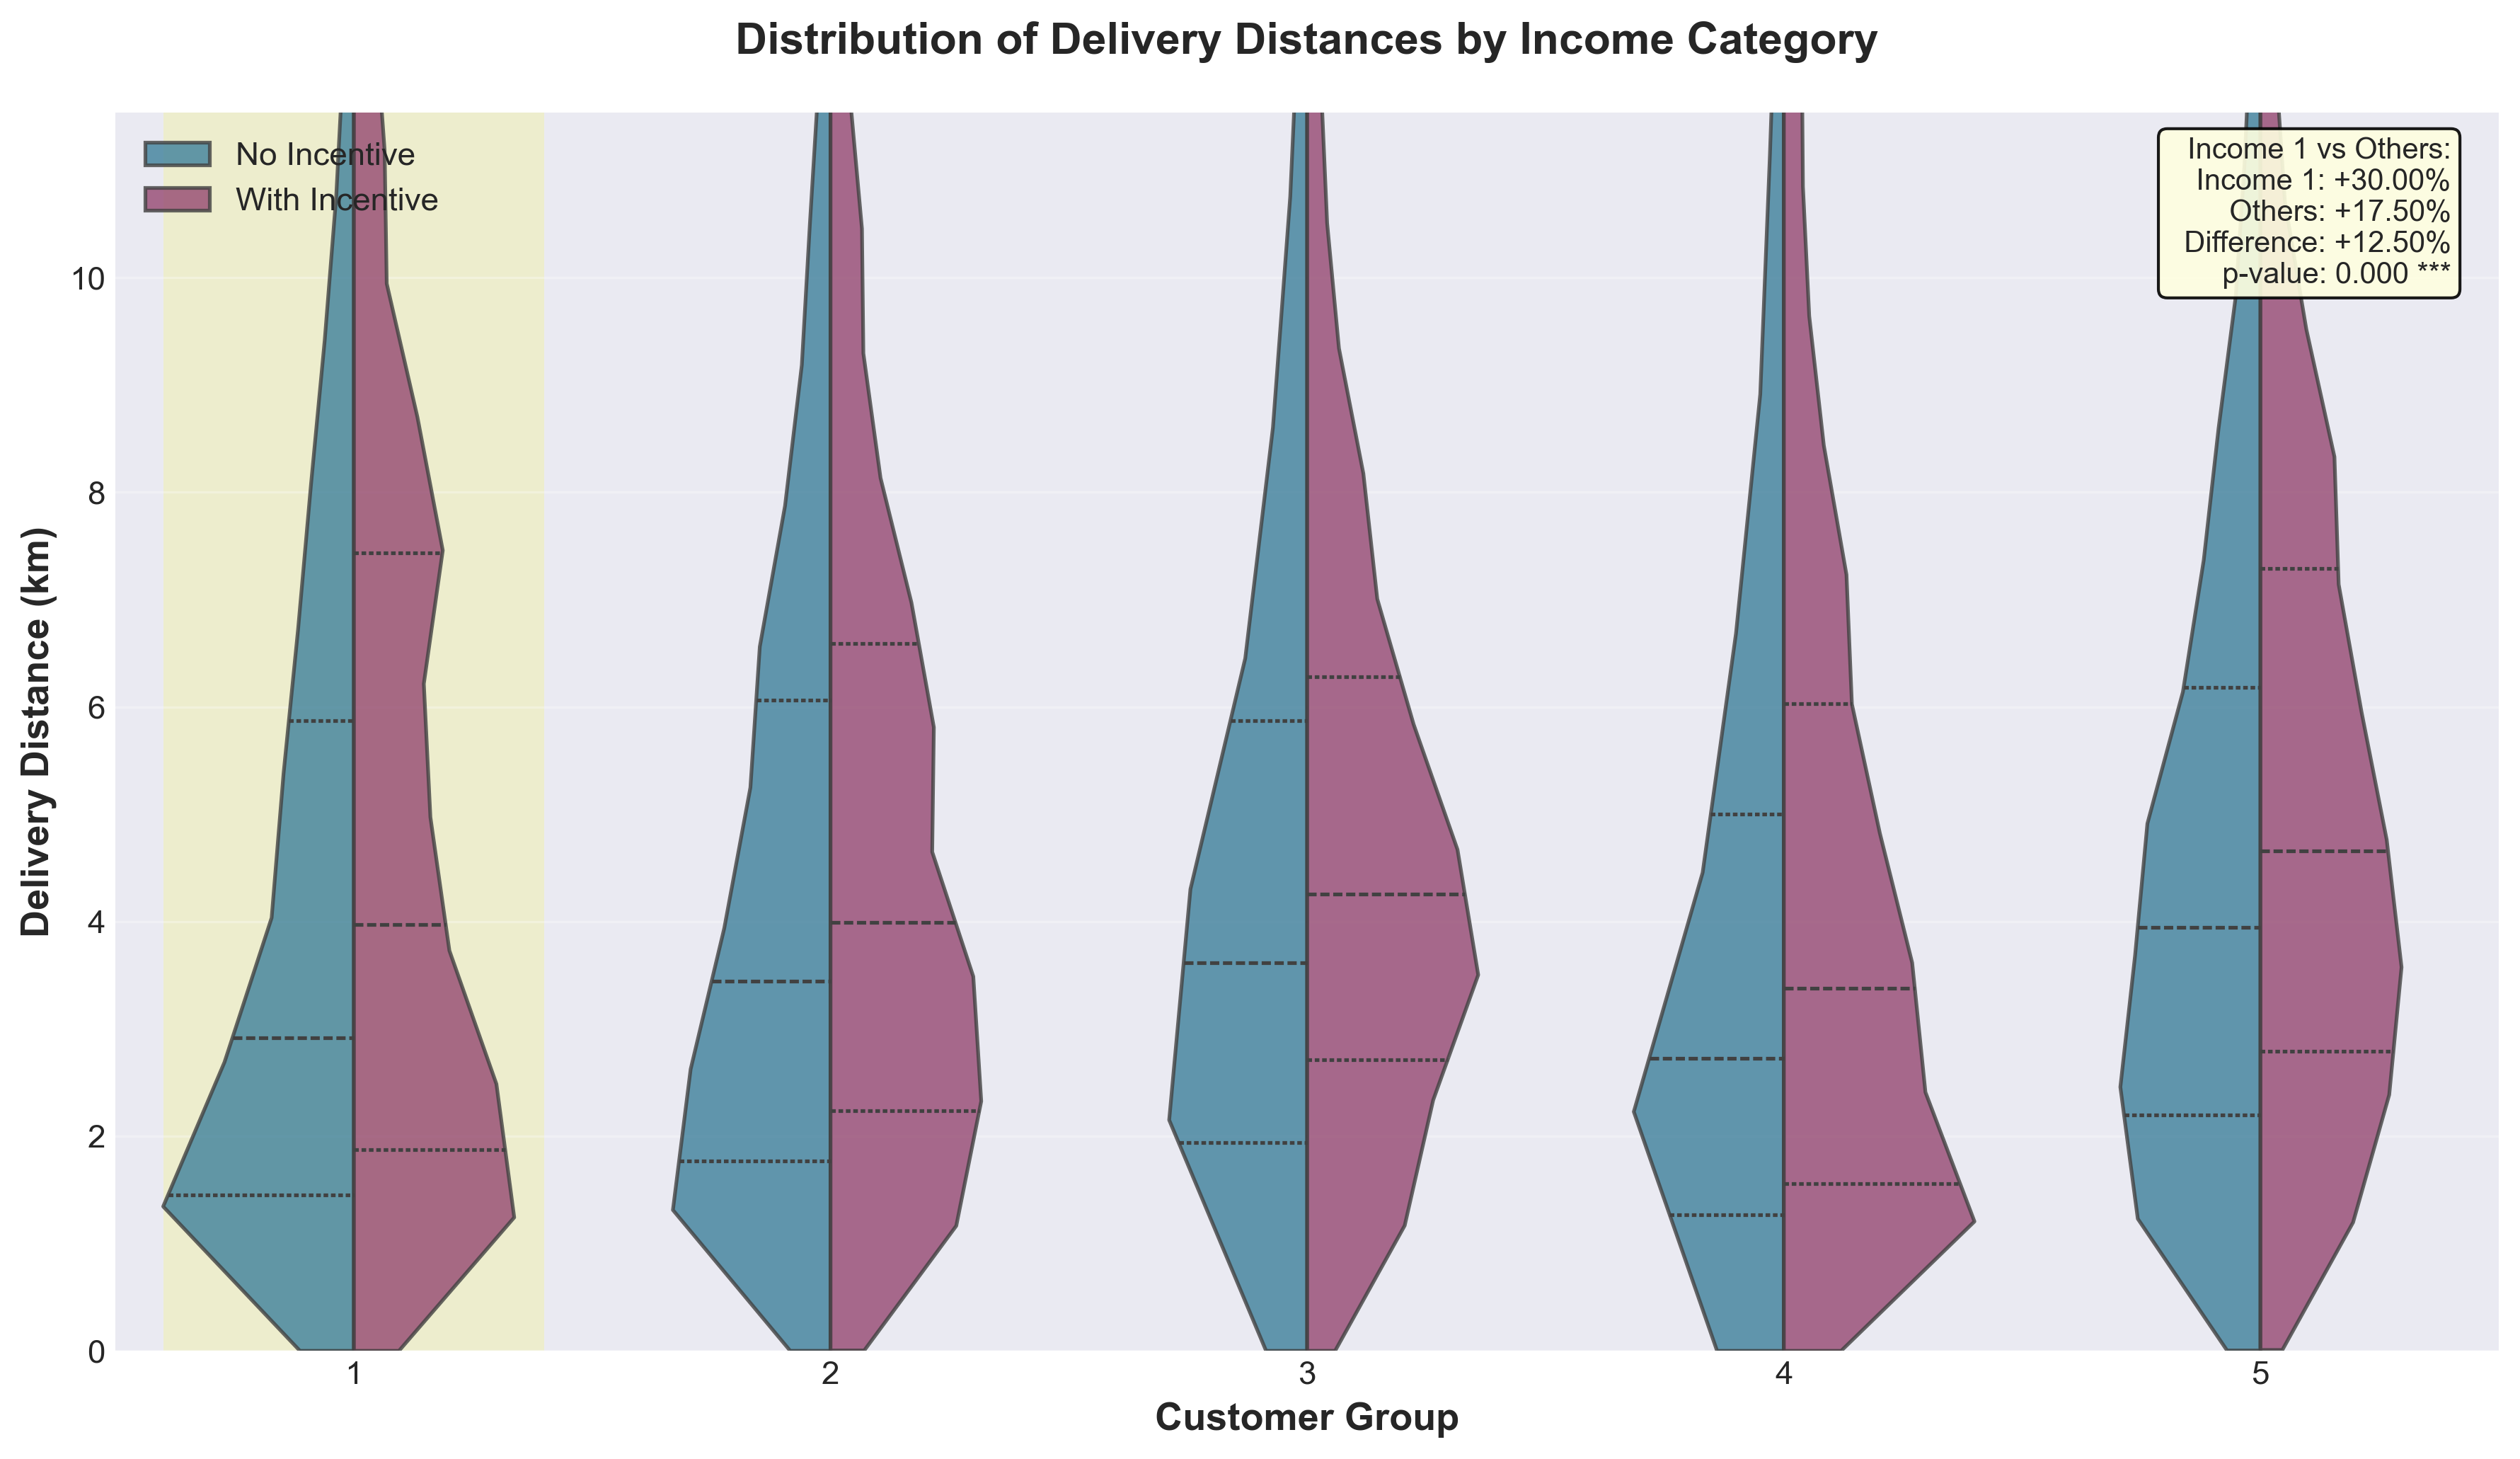

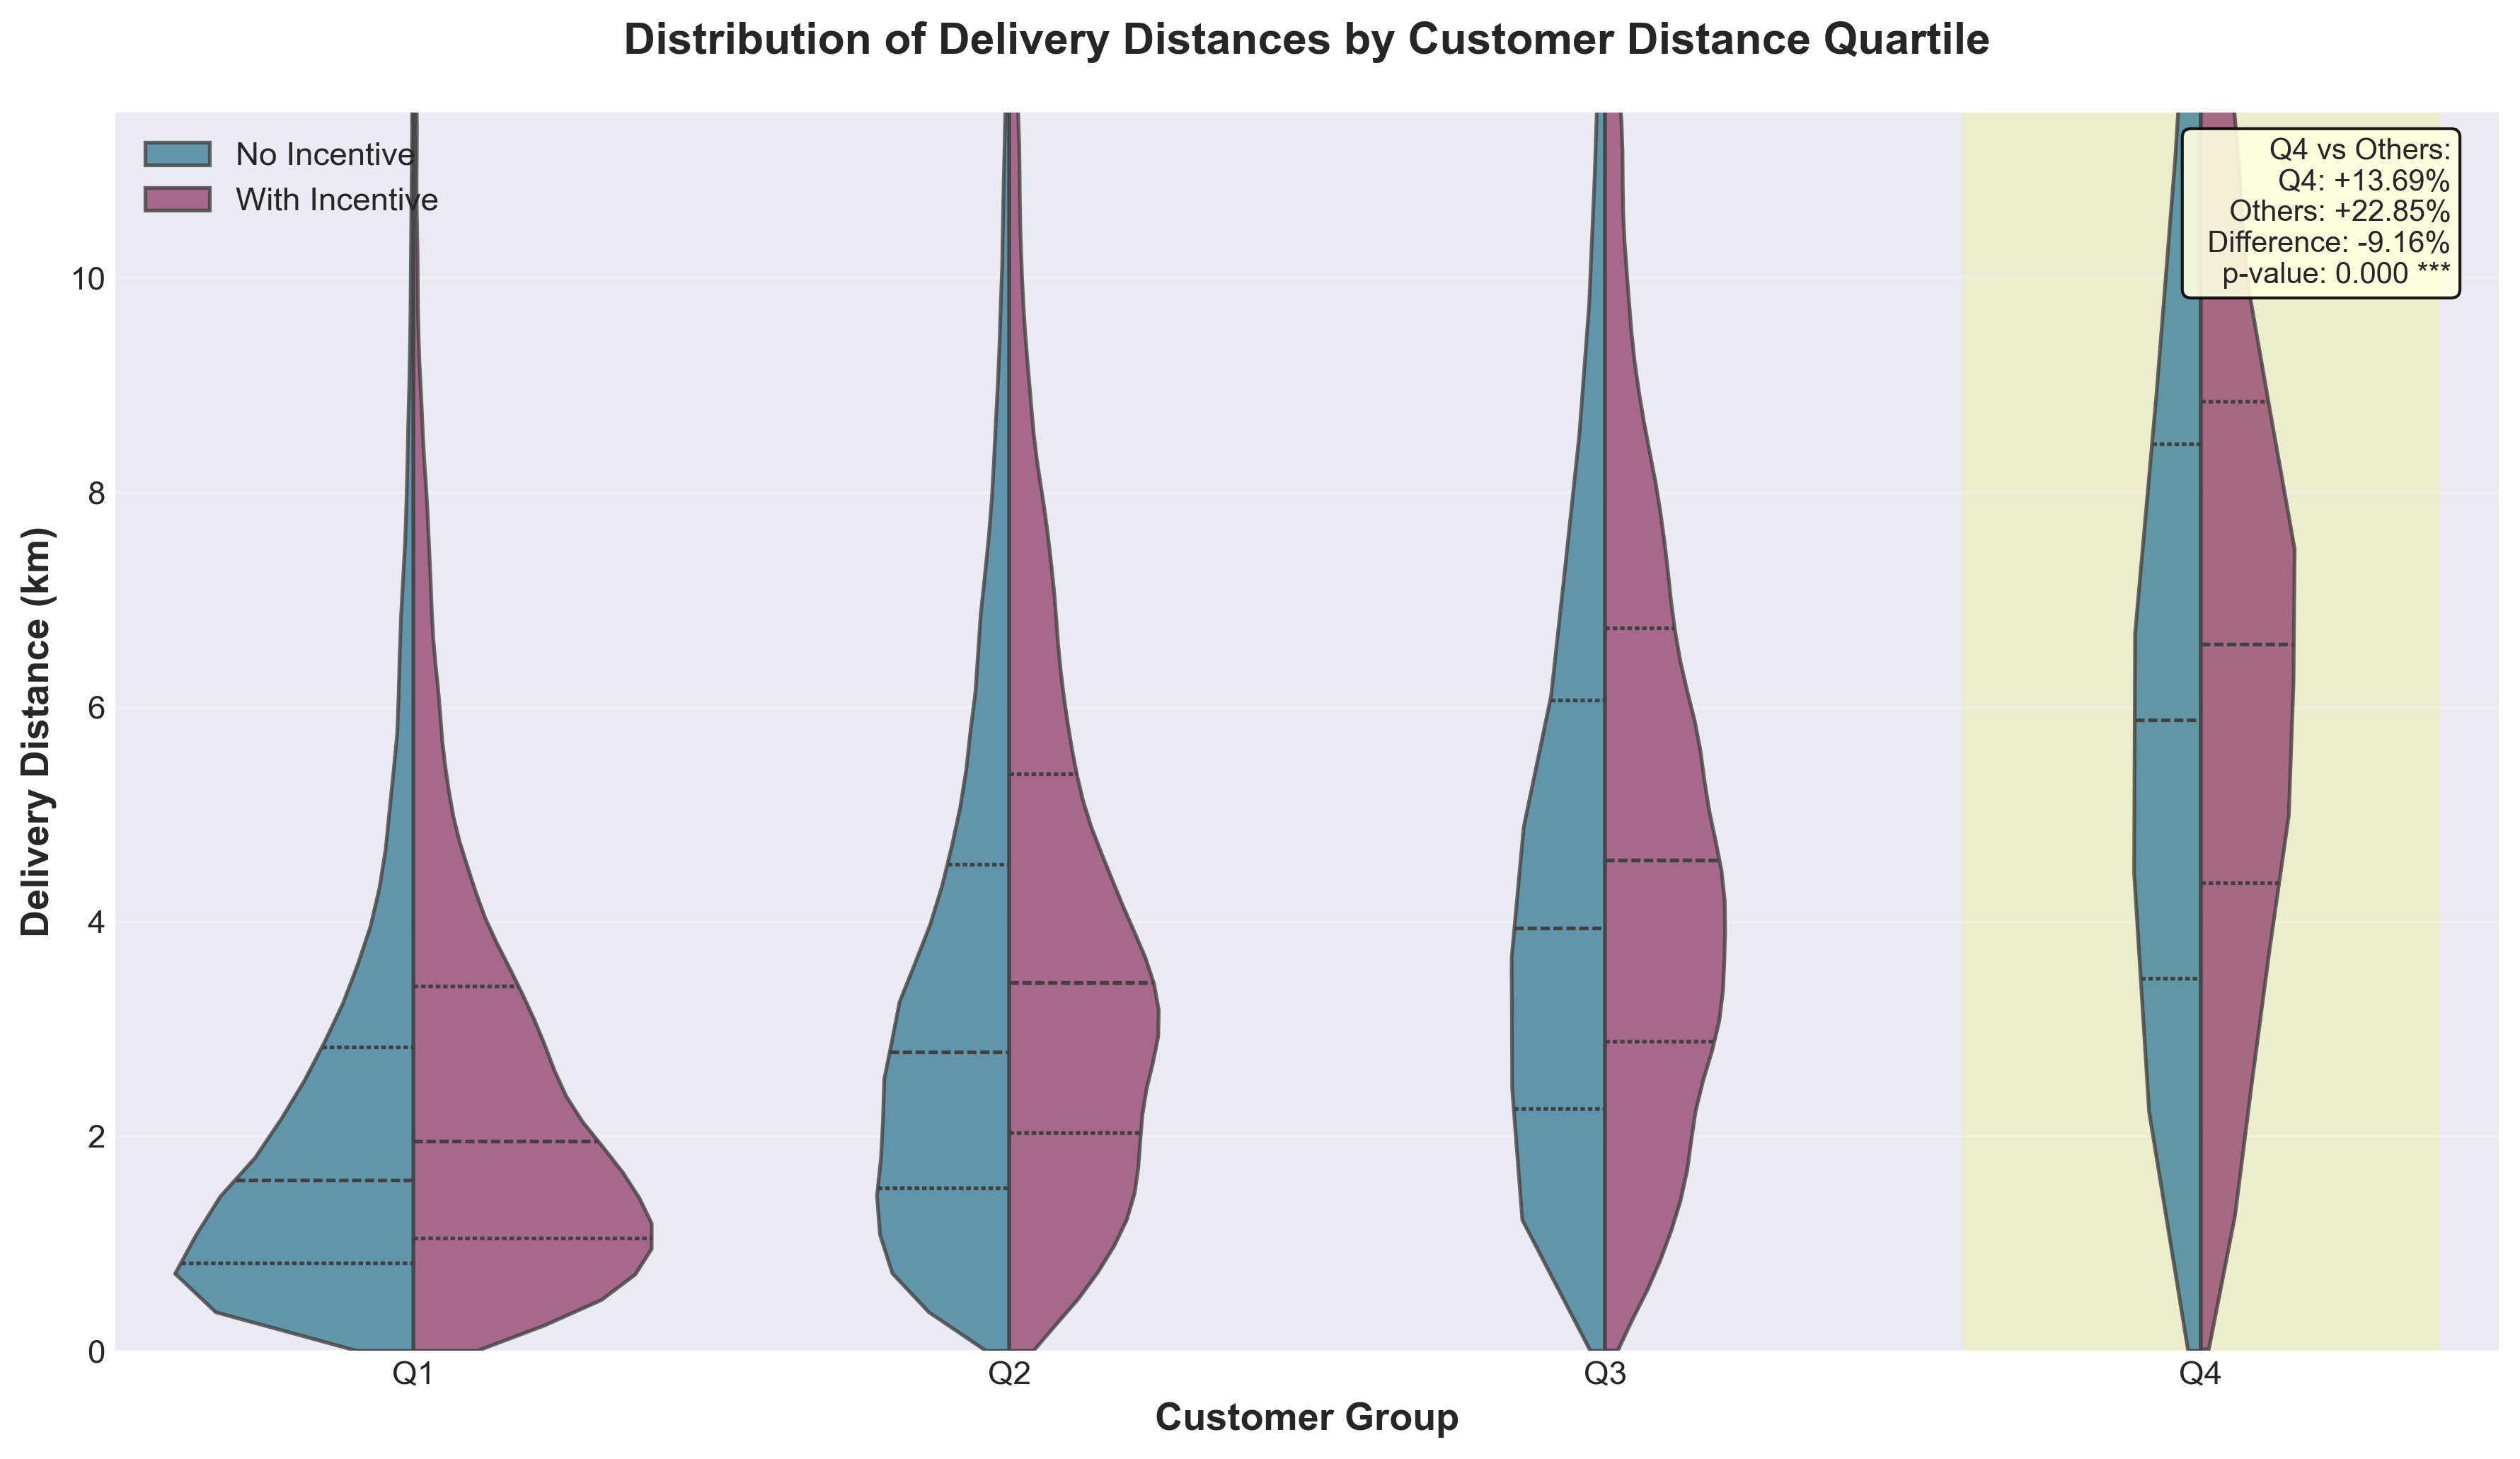

In [25]:
# ============================================================================
# ADDITIONAL VISUALIZATIONS: SPLIT VIOLIN PLOTS
# ============================================================================
# Run this code AFTER the main analysis script has been executed
# Requires: df_analysis, df_income_results, df_distance_results to be in memory

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
import seaborn as sns


# ============================================================================
# 1. SPLIT VIOLIN PLOTS
# ============================================================================

def prepare_violin_data(df, group_col, group_values):
    """Prepare data for split violin plots and save for R."""
    data_list = []
    
    for group_val in group_values:
        subset = df[df[group_col] == group_val]
        
        # Get distances for each incentive category
        no_inc = subset[subset['incentive_cat'] == 'no_incentive']['distance_km'].values
        with_inc = subset[subset['incentive_cat'] == 'with_incentive']['distance_km'].values
        
        # Store for violin plot
        for dist in no_inc:
            data_list.append({
                'group': group_val,
                'distance_km': dist,
                'incentive': 'no_incentive'
            })
        
        for dist in with_inc:
            data_list.append({
                'group': group_val,
                'distance_km': dist,
                'incentive': 'with_incentive'
            })
    
    return pd.DataFrame(data_list)


def plot_split_violin(df, group_col, group_values, title='', output_path=None, 
                      highlight_groups=None, comparison_text=None, ylim=None):
    """Create split violin plot showing distributions for each group."""
    
    # Prepare data
    df_plot = prepare_violin_data(df, group_col, group_values)
    
    # Save for R
    if output_path:
        df_plot.to_csv(output_path, index=False)
        print(f"Saved violin plot data to: {output_path}")
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Use seaborn's violin plot with split option
    sns.violinplot(
        data=df_plot, 
        x='group', 
        y='distance_km', 
        hue='incentive',
        split=True,
        inner='quartile',
        palette={'no_incentive': '#2E86AB', 'with_incentive': '#A23B72'},
        ax=ax,
        alpha=0.8,
        cut=0  # Don't extend beyond actual data range
    )
    
    # Set y-axis limit to exclude outliers if specified
    if ylim is not None:
        ax.set_ylim(ylim)
    else:
        # Auto-calculate reasonable ylim based on 95th percentile
        upper_limit = df_plot['distance_km'].quantile(0.95)
        ax.set_ylim(0, upper_limit * 1.1)
    
    # Customize
    ax.set_xlabel('Customer Group', fontsize=13, fontweight='bold')
    ax.set_ylabel('Delivery Distance (km)', fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Update legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['No Incentive', 'With Incentive'], 
             loc='upper left', framealpha=0.95)
    
    # Highlight specific groups if requested
    if highlight_groups:
        for i, g in enumerate(group_values):
            if g in highlight_groups:
                # Add a background highlight
                rect = Rectangle((i - 0.4, ax.get_ylim()[0]), 0.8, 
                               ax.get_ylim()[1] - ax.get_ylim()[0],
                               facecolor='yellow', alpha=0.15, zorder=0)
                ax.add_patch(rect)
    
    # Add comparison text box if provided
    if comparison_text:
        ax.text(0.98, 0.98, comparison_text, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='lightyellow', 
                         alpha=0.9, edgecolor='black'))
    
    plt.tight_layout()
    return fig, ax


# ============================================================================
# HELPER FUNCTIONS FOR TESTING
# ============================================================================

def test_coefficient_difference(df_results, target_group, group_col='subset'):
    """Test if target group coefficient differs significantly from others."""
    
    target_row = df_results[df_results[group_col] == target_group].iloc[0]
    others_rows = df_results[df_results[group_col] != target_group]
    
    # Target group stats
    coef_target = target_row['coef']
    se_target = target_row['se']
    
    # Average of other groups (weighted by inverse variance)
    weights = 1 / (others_rows['se'] ** 2)
    coef_others = np.average(others_rows['coef'], weights=weights)
    se_others = np.sqrt(1 / weights.sum())
    
    # T-test for difference
    diff = coef_target - coef_others
    se_diff = np.sqrt(se_target**2 + se_others**2)
    t_stat = diff / se_diff
    
    # Two-tailed p-value
    from scipy.stats import norm
    p_val = 2 * (1 - norm.cdf(abs(t_stat)))
    
    pct_target = (np.exp(coef_target) - 1) * 100
    pct_others = (np.exp(coef_others) - 1) * 100
    
    return {
        'target_group': target_group,
        'target_pct': pct_target,
        'others_pct': pct_others,
        'difference': pct_target - pct_others,
        't_stat': t_stat,
        'p_value': p_val,
        'significant': p_val < 0.05
    }


def format_comparison_text(test_result):
    """Format test results into text for plot annotation."""
    
    sig_marker = '***' if test_result['p_value'] < 0.01 else '**' if test_result['p_value'] < 0.05 else '*' if test_result['p_value'] < 0.10 else ''
    
    text = f"{test_result['target_group']} vs Others:\n"
    text += f"  {test_result['target_group']}: {test_result['target_pct']:+.2f}%\n"
    text += f"  Others: {test_result['others_pct']:+.2f}%\n"
    text += f"  Difference: {test_result['difference']:+.2f}%\n"
    text += f"  p-value: {test_result['p_value']:.3f} {sig_marker}"
    
    return text


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    print("\n" + "="*80)
    print("ADDITIONAL VISUALIZATIONS: SPLIT VIOLIN PLOTS")
    print("="*80)
    
    # Check if required data exists
    try:
        df_analysis
        df_income_results
        df_distance_results
        print("\n✓ Required data found in memory")
    except NameError as e:
        print(f"\nERROR: {e}")
        print("\nPlease run the main analysis script first!")
        print("This script requires: df_analysis, df_income_results, df_distance_results")
        exit()
    
    # Get group values
    income_cats = sorted(df_analysis['income_category'].dropna().unique())
    income_cats_labeled = ['Income ' + str(i) for i in income_cats]
    quartiles = ['Q1', 'Q2', 'Q3', 'Q4']
    
    # Statistical tests (for comparison text)
    print("\n[1/2] Running statistical tests...")
    income_test = test_coefficient_difference(df_income_results, 'Income 1')
    distance_test = test_coefficient_difference(df_distance_results, 'Q4')
    
    income_comparison_text = format_comparison_text(income_test)
    distance_comparison_text = format_comparison_text(distance_test)
    
    # ========================================================================
    # INCOME VISUALIZATIONS
    # ========================================================================
    
    print("\n" + "="*80)
    print("INCOME CATEGORY VISUALIZATIONS")
    print("="*80)
    
    print("\nCreating split violin plot for income...")
    fig_income_violin, _ = plot_split_violin(
        df_analysis,
        group_col='income_category',
        group_values=income_cats,
        title='Distribution of Delivery Distances by Income Category',
        output_path='./grouped_exports/income_violin_data.csv',
        highlight_groups=[1],  # Highlight income category 1
        comparison_text=income_comparison_text
    )
    
    # ========================================================================
    # DISTANCE QUARTILE VISUALIZATIONS
    # ========================================================================
    
    print("\n" + "="*80)
    print("DISTANCE QUARTILE VISUALIZATIONS")
    print("="*80)
    
    print("\nCreating split violin plot for distance quartiles...")
    fig_dist_violin, _ = plot_split_violin(
        df_analysis,
        group_col='customer_dist_quartile',
        group_values=quartiles,
        title='Distribution of Delivery Distances by Customer Distance Quartile',
        output_path='./grouped_exports/distance_violin_data.csv',
        highlight_groups=['Q4'],
        comparison_text=distance_comparison_text
    )
    
    # ========================================================================
    # SUMMARY   
    # ========================================================================
    
    print("\n" + "="*80)
    print("VISUALIZATION SUMMARY")
    print("="*80)
    print("\nCreated 2 plots:")
    print("  • Split violin plot for income categories")
    print("  • Split violin plot for distance quartiles")
    print("\nSaved 2 CSV files for R:")
    print("  • income_violin_data.csv")
    print("  • distance_violin_data.csv")
    print("\nAll files saved to: ./grouped_exports/")
    print("\nNote: Y-axis limited to 95th percentile to handle outliers")
    
    plt.show()

In [26]:
df_analysis = prepare_data(dubai_df, gdf_webmerc)
df_analysis

DATA PREPROCESSING

[1/8] Calculating distances...
   Orders: 3,873,149, Customers: 823,694

[2/8] Creating incentive categories...
incentive_cat
no_incentive      3627318
with_incentive     245831
Name: count, dtype: int64

[3/8] Merging income data...
   Orders after merge: 3,873,382
   Income categories:
income_category
4    1163809
2     850635
3     762349
1     638465
5     458124
Name: count, dtype: int64

[4/8] Calculating average fee per km control...

[5/8] Filtering customers with >5 orders...
   Customers: 362,042, Orders: 3,279,792

[6/8] Filtering customers with incentive variation...
   Customers with variation: 121,896, Orders: 1,536,805

[7/8] Creating customer distance quartiles...
   Quartile distribution:
customer_dist_quartile
Q1    342214
Q2    423615
Q3    420853
Q4    350123
Name: count, dtype: int64

[8/8] Creating variables...

   Final sample: 1,536,805 orders, 121,896 customers
   Mean distance: 4.19 km


,order_id,account_id,vendor_id,location_id,vendor_location,main_cuisine,vertical_class,secondary_verticals,delivery_fee_amount_lc,service_fee_amount_lc,...,incentive_cat,income_category,fee_per_km,avg_fee_per_km,customer_dist_quartile,log_distance,log_basket,is_food,is_weekend,has_incentive
2,1342216273,15757489,699699,545,POINT(55.2117804 25.1195374),grills,food,NaN,7.50,0.90,...,no_incentive,3,1.347699,1.722144,Q3,1.716504,3.433987,1,0,0
17,1341487806,24080485,680163,653,POINT(55.1996034 25.0533358),pharmacy,non-food,NaN,7.00,0.90,...,no_incentive,3,2.009425,3.583668,Q1,1.248061,3.238678,0,0,0
24,1342476393,5534040,605700,653,POINT(55.247002209209 25.04799970264),pasta,food,NaN,0.00,3.00,...,no_incentive,2,0.000000,1.548418,Q1,0.318643,4.615121,1,0,0
38,1341946458,23845255,27567,531,POINT(55.3183329999999 25.267392),arabic,food,NaN,5.50,0.93,...,no_incentive,2,1.868306,1.353035,Q2,1.079716,3.465736,1,0,0
42,1342613694,27147379,705567,658,POINT(55.4188440288682 25.2175848247516),pizza,food,NaN,8.50,1.56,...,no_incentive,2,1.001460,1.952582,Q4,2.138607,3.970292,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3873371,1184081934,528486,647859,632,POINT(55.4101219 25.1565589),biryani,food,NaN,7.50,0.90,...,no_incentive,4,1.948138,1.979855,Q3,1.348029,3.401197,1,0,0
3873372,1183866838,6196203,44691,588,POINT(55.260209 25.184257),grocery,non-food,NaN,6.49,1.00,...,no_incentive,1,1.691789,2.760770,Q1,1.344476,3.536602,0,0,0
3873375,1183281665,4796219,690891,616,POINT(55.1856257 25.0382649),burgers,food,NaN,0.00,0.90,...,no_incentive,2,0.000000,3.277235,Q2,1.633775,3.433987,1,0,0
3873378,1183861979,791786,685734,504,POINT(55.2244608 25.0589326),turkish,food,NaN,5.00,2.52,...,no_incentive,3,3.150057,11.350068,Q2,0.462018,4.442651,1,0,0


In [27]:
df_incentivized = df_analysis[df_analysis['delivery_incentive_lc'] > 0]
df_noincentives = df_analysis[df_analysis['delivery_incentive_lc'] == 0]

In [28]:
flow_incentivized = build_dubai_flows(df_incentivized, gdf_webmerc, use_osrm=True)
flow_noincentives = build_dubai_flows(df_noincentives, gdf_webmerc, use_osrm=True)

Step 1: Computing basic metrics...
Step 2: Creating bounding box...
Step 3: Filtering income polygons...
Step 4: Generating H3 cells...
Step 5: Filtering trips to bounding box...
Filtered to 198429 trips within bbox
Step 6: Assigning H3 indices...
Step 7: Computing aggregated counts...
Step 8: Aggregating flows...
Created 6337 origin-destination pairs
Step 9: Merging counts...
Step 10: Assigning income categories...
Step 11: Assigning population proxy...
Population proxy assigned: 5758974 unique customers across 6337 cells
Step 12: Computing H3 centroid euclidean distances...
Computing euclidean distances between H3 cell centroids...
H3 centroid distances: mean=7.96 km, median=7.70 km
Step 13: Computing driving distances...
Computing driving distances using OSRM API (no network download needed)...
Loaded 17945 cached distances from distance_cache.pkl
All distances already cached!

Overall: 6337/6337 driving distances (100.0%)

=== FLOW DATAFRAME COMPLETE ===
Total OD pairs: 6337
Column

In [29]:
flow_incentivized = fill_income_from_neighbors(flow_incentivized, "origin")
flow_incentivized = fill_income_from_neighbors(flow_incentivized, "destination")
flow_incentivized = fill_travel_time_with_nearest(flow_incentivized)
flow_noincentives = fill_income_from_neighbors(flow_noincentives, "origin")
flow_noincentives = fill_income_from_neighbors(flow_noincentives, "destination")
flow_noincentives = fill_travel_time_with_nearest(flow_noincentives)

In [30]:
flow_incentivized.to_csv('./grouped_exports/dubai_incentivized.csv')
flow_noincentives.to_csv('./grouped_exports/dubai_noincentives.csv')